In [ ]:
# Étape 1 — Monter Google Drive et localiser le fichier NASA

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

nom_fichier = "mooninfo_2026.json"
racine_drive = Path("/content/drive/MyDrive")

fichiers_trouves = list(racine_drive.rglob(nom_fichier))

if not fichiers_trouves:
    raise FileNotFoundError(
        f"Le fichier {nom_fichier} n'a pas été trouvé dans Google Drive."
    )

chemin_json = fichiers_trouves[0]

print("Fichier trouvé :")
print(chemin_json)
print(f"Nombre de correspondances : {len(fichiers_trouves)}")

Mounted at /content/drive
Fichier trouvé :
/content/drive/MyDrive/mooninfo_2026.json
Nombre de correspondances : 1


In [ ]:
# Étape 2 — Chargement et contrôle des données NASA

import json
import pandas as pd

with open(chemin_json, "r") as f:
    data = json.load(f)

df = pd.json_normalize(data)

print("="*60)
print("Dimensions :", df.shape)
print("="*60)

print("\nColonnes :")
print(df.columns.tolist())

print("\nPremières lignes :")
display(df.head())

print("\nValeurs manquantes :")
display(df.isna().sum())

print("\nTypes :")
display(df.dtypes)

Dimensions : (8760, 12)

Colonnes :
['time', 'phase', 'age', 'diameter', 'distance', 'posangle', 'j2000.ra', 'j2000.dec', 'subsolar.lon', 'subsolar.lat', 'subearth.lon', 'subearth.lat']

Premières lignes :


,time,phase,age,diameter,distance,posangle,j2000.ra,j2000.dec,subsolar.lon,subsolar.lat,subearth.lon,subearth.lat
0,01 Jan 2026 00:00 UT,91.40,11.928,1985.1,361045,349.893,4.2348,26.3373,32.520,-1.346,-1.279,-6.556
1,01 Jan 2026 01:00 UT,91.68,11.970,1985.5,360985,350.124,4.2803,26.4505,32.014,-1.346,-1.201,-6.562
2,01 Jan 2026 02:00 UT,91.95,12.012,1985.8,360927,350.358,4.3260,26.5604,31.509,-1.345,-1.124,-6.566
3,01 Jan 2026 03:00 UT,92.22,12.053,1986.1,360873,350.593,4.3717,26.6671,31.004,-1.344,-1.046,-6.570
4,01 Jan 2026 04:00 UT,92.49,12.095,1986.4,360820,350.830,4.4175,26.7705,30.498,-1.344,-0.968,-6.573



Valeurs manquantes :


,0
time,0
phase,0
age,0
diameter,0
distance,0
posangle,0
j2000.ra,0
j2000.dec,0
subsolar.lon,0
subsolar.lat,0



Types :


,0
time,object
phase,float64
age,float64
diameter,float64
distance,int64
posangle,float64
j2000.ra,float64
j2000.dec,float64
subsolar.lon,float64
subsolar.lat,float64


In [3]:
# Étape 3 — Validation temporelle

import pandas as pd

# Conversion en datetime
df["datetime"] = pd.to_datetime(
    df["time"],
    format="%d %b %Y %H:%M UT"
)

# Tri de sécurité
df = df.sort_values("datetime").reset_index(drop=True)

# Pas entre deux observations
delta = df["datetime"].diff().dropna()

print("="*60)
print("Première date :", df["datetime"].min())
print("Dernière date :", df["datetime"].max())
print()

print("Pas minimum :", delta.min())
print("Pas maximum :", delta.max())
print()

print("Nombre de pas différents :")
print(delta.value_counts())

print("="*60)

# Doublons
print("Doublons temporels :", df["datetime"].duplicated().sum())

Première date : 2026-01-01 00:00:00
Dernière date : 2026-12-31 23:00:00

Pas minimum : 0 days 01:00:00
Pas maximum : 0 days 01:00:00

Nombre de pas différents :
datetime
0 days 01:00:00    8759
Name: count, dtype: int64
Doublons temporels : 0


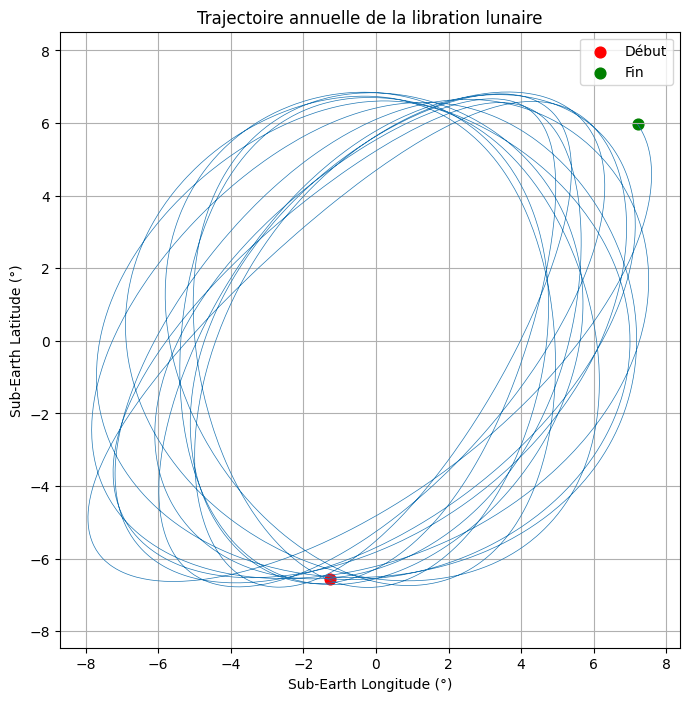

In [4]:
# Étape 4 — Géométrie de la libration

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.plot(
    df["subearth.lon"],
    df["subearth.lat"],
    lw=0.5
)

plt.scatter(
    df["subearth.lon"].iloc[0],
    df["subearth.lat"].iloc[0],
    color="red",
    s=60,
    label="Début"
)

plt.scatter(
    df["subearth.lon"].iloc[-1],
    df["subearth.lat"].iloc[-1],
    color="green",
    s=60,
    label="Fin"
)

plt.xlabel("Sub-Earth Longitude (°)")
plt.ylabel("Sub-Earth Latitude (°)")
plt.title("Trajectoire annuelle de la libration lunaire")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [5]:
# Étape 5 — Construction du vecteur géométrique

import numpy as np

lon = np.deg2rad(df["subearth.lon"].to_numpy())
lat = np.deg2rad(df["subearth.lat"].to_numpy())

X = np.cos(lat) * np.cos(lon)
Y = np.cos(lat) * np.sin(lon)
Z = np.sin(lat)

print("Nombre de points :", len(X))

print("\nPremiers vecteurs :")
for i in range(5):
    print(
        f"{i:2d} : "
        f"({X[i]: .6f}, {Y[i]: .6f}, {Z[i]: .6f})"
    )

# Vérification : norme = 1
norme = np.sqrt(X**2 + Y**2 + Z**2)

print("\nNorme moyenne :", norme.mean())
print("Norme min     :", norme.min())
print("Norme max     :", norme.max())

Nombre de points : 8760

Premiers vecteurs :
 0 : ( 0.993213, -0.022175, -0.114174)
 1 : ( 0.993231, -0.020823, -0.114278)
 2 : ( 0.993250, -0.019488, -0.114348)
 3 : ( 0.993267, -0.018135, -0.114417)
 4 : ( 0.993285, -0.016783, -0.114469)

Norme moyenne : 1.0
Norme min     : 0.9999999999999998
Norme max     : 1.0000000000000002


In [6]:
# Étape 6 — Distance de transition GVH sur la sphère

import numpy as np
import pandas as pd

# Matrice des vecteurs unitaires
XYZ = np.column_stack([X, Y, Z])

# Différences entre états successifs
dXYZ = np.diff(XYZ, axis=0)

# Distance euclidienne entre deux points successifs sur la sphère unité
D_T = np.linalg.norm(dXYZ, axis=1)

# Produit scalaire entre vecteurs successifs
dot = np.sum(XYZ[:-1] * XYZ[1:], axis=1)
dot = np.clip(dot, -1.0, 1.0)

# Distance angulaire géodésique
delta_psi_rad = np.arccos(dot)
delta_psi_deg = np.rad2deg(delta_psi_rad)

# Contrôle théorique : D_T = 2 sin(delta_psi / 2)
D_T_check = 2.0 * np.sin(delta_psi_rad / 2.0)
erreur_identite = np.abs(D_T - D_T_check)

# Ajout au dataframe
df["D_T"] = np.nan
df.loc[1:, "D_T"] = D_T

df["delta_psi_deg"] = np.nan
df.loc[1:, "delta_psi_deg"] = delta_psi_deg

print("=" * 60)
print("Nombre de transitions :", len(D_T))
print()
print("D_T moyen             :", D_T.mean())
print("D_T minimum           :", D_T.min())
print("D_T maximum           :", D_T.max())
print("Écart-type D_T        :", D_T.std(ddof=1))
print()
print("Δψ moyen (degrés)     :", delta_psi_deg.mean())
print("Δψ minimum (degrés)   :", delta_psi_deg.min())
print("Δψ maximum (degrés)   :", delta_psi_deg.max())
print()
print("Erreur max identité   :", erreur_identite.max())
print("Erreur moyenne        :", erreur_identite.mean())
print("=" * 60)

Nombre de transitions : 8759

D_T moyen             : 0.001075680750031748
D_T minimum           : 0.0005128427450185129
D_T maximum           : 0.0018479360239616923
Écart-type D_T        : 0.0002285163920935054

Δψ moyen (degrés)     : 0.06163197046446902
Δψ minimum (degrés)   : 0.02938372516945027
Δψ maximum (degrés)   : 0.1058789500460865

Erreur max identité   : 5.709690532873513e-13
Erreur moyenne        : 7.536307532724111e-14


In [7]:
# Étape 7 — Observables GVH fondamentales

import numpy as np
import pandas as pd

# Paramètre de seuil
q = 0.95

# Observables globales
D_T_mean = np.mean(D_T)
S_T = np.std(D_T, ddof=1)
S_T_norm = S_T / D_T_mean

# Normalisation GVH
u = D_T / np.max(D_T)

# Seuil critique
D_c = np.quantile(D_T, q)
u_c = np.quantile(u, q)

# Fraction supercritique
R_super = np.mean(D_T > D_c)

# Tableau résumé
observables_base = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "u_c",
        "R_super"
    ],
    "Valeur": [
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        u_c,
        R_super
    ]
})

display(observables_base)

print("=" * 60)
print(f"Quantile utilisé : q = {q}")
print(f"Nombre de transitions supercritiques : {np.sum(D_T > D_c)}")
print(f"Nombre total de transitions          : {len(D_T)}")
print("=" * 60)

,Observable,Valeur
0,D_T_mean,0.001076
1,S_T,0.000229
2,S_T_norm,0.212439
3,D_c,0.001511
4,u_c,0.817925
5,R_super,0.050006


Quantile utilisé : q = 0.95
Nombre de transitions supercritiques : 438
Nombre total de transitions          : 8759


,Observable,Valeur
0,A_H,1.469222
1,B_H,2.027090
2,R2_H,0.756209
3,RMSE_H,0.201322


Nombre de seuils utilisés : 120
A_H                      : 1.4692221879699126
B_H                      : 2.027090302366326
R²                       : 0.7562090933813008
RMSE                     : 0.2013217583019228


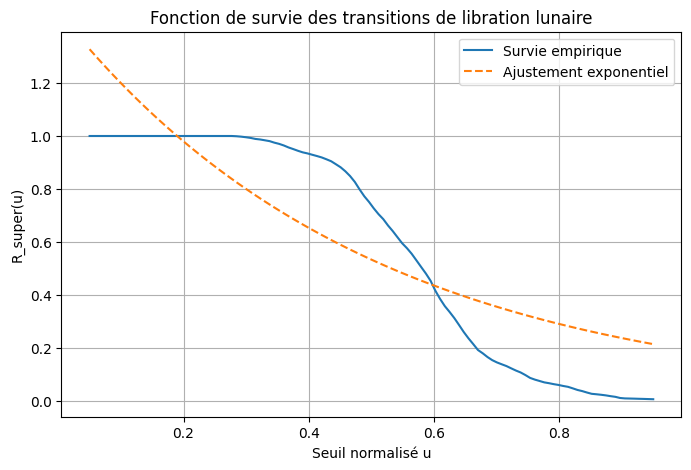

In [8]:
# Étape 8 — Fonction de survie GVH et ajustement exponentiel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Grille de seuils
u_grid = np.linspace(0.05, 0.95, 120)

# Fonction de survie empirique
R_emp = np.array([
    np.mean(u > seuil)
    for seuil in u_grid
])

# On exclut les valeurs nulles pour le fit logarithmique/exponentiel
mask = R_emp > 0

u_fit = u_grid[mask]
R_fit = R_emp[mask]

# Modèle exponentiel
def modele_exponentiel(u, A_H, B_H):
    return A_H * np.exp(-B_H * u)

# Ajustement
popt, pcov = curve_fit(
    modele_exponentiel,
    u_fit,
    R_fit,
    p0=[1.0, 3.0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=20000
)

A_H, B_H = popt

# Prédictions
R_pred = modele_exponentiel(u_fit, A_H, B_H)

# Diagnostics
residus = R_fit - R_pred

ss_res = np.sum(residus**2)
ss_tot = np.sum((R_fit - np.mean(R_fit))**2)

R2_H = 1.0 - ss_res / ss_tot
RMSE_H = np.sqrt(np.mean(residus**2))

# Tableau résumé
fit_resume = pd.DataFrame({
    "Observable": [
        "A_H",
        "B_H",
        "R2_H",
        "RMSE_H"
    ],
    "Valeur": [
        A_H,
        B_H,
        R2_H,
        RMSE_H
    ]
})

display(fit_resume)

print("=" * 60)
print("Nombre de seuils utilisés :", len(u_fit))
print("A_H                      :", A_H)
print("B_H                      :", B_H)
print("R²                       :", R2_H)
print("RMSE                     :", RMSE_H)
print("=" * 60)

# Figure
plt.figure(figsize=(8, 5))

plt.plot(
    u_grid,
    R_emp,
    label="Survie empirique"
)

plt.plot(
    u_fit,
    R_pred,
    linestyle="--",
    label="Ajustement exponentiel"
)

plt.xlabel("Seuil normalisé u")
plt.ylabel("R_super(u)")
plt.title("Fonction de survie des transitions de libration lunaire")
plt.grid(True)
plt.legend()
plt.show()

,Modèle,R2,RMSE,SSE,AIC,Paramètre 1,Paramètre 2
0,Logistique,0.999366,0.010269,0.012655,-1094.863548,0.578276,14.399668
1,Weibull,0.997832,0.018984,0.043249,-947.393896,0.621350,5.615800
2,Exponentielle,0.756209,0.201322,4.863654,-380.684207,1.469222,2.027090


Exponentielle : A = 1.4692221879699126  B = 2.027090302366326
Weibull       : λ = 0.6213497397888901  k = 5.615800302085193
Logistique    : u0 = 0.5782759832752148  k = 14.399667783339385

Meilleur modèle selon l'AIC :
Logistique


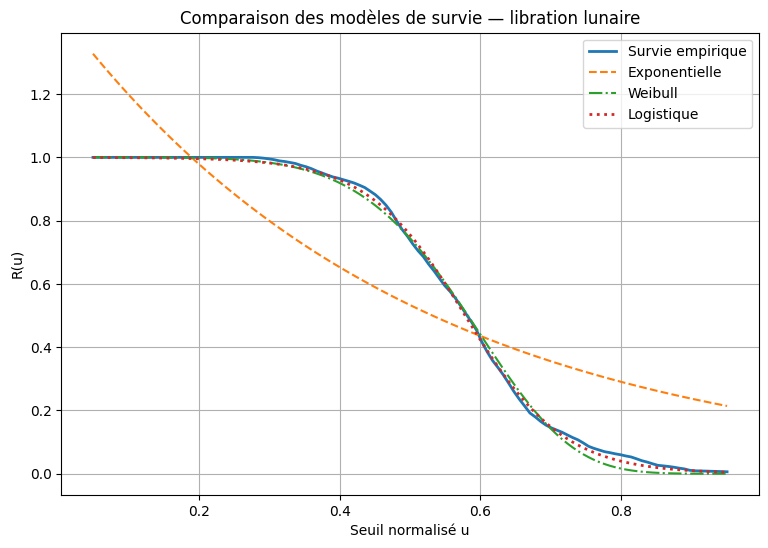

In [9]:
# Étape 9 — Comparaison de plusieurs modèles de survie

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# Modèles
# ------------------------------------------------------------

def survie_exponentielle(u, A, B):
    return A * np.exp(-B * u)

def survie_weibull(u, lam, k):
    return np.exp(-((u / lam) ** k))

def survie_logistique(u, u0, k):
    return 1.0 / (1.0 + np.exp(k * (u - u0)))

# Les données empiriques ont déjà été calculées :
# u_grid, R_emp

mask = R_emp > 0
x = u_grid[mask]
y = R_emp[mask]

resultats = []
predictions = {}

def diagnostics_modele(nom, y_obs, y_pred, n_param):
    residus = y_obs - y_pred

    sse = np.sum(residus**2)
    rmse = np.sqrt(np.mean(residus**2))

    ss_tot = np.sum((y_obs - np.mean(y_obs))**2)
    r2 = 1.0 - sse / ss_tot

    n = len(y_obs)

    # AIC fondé sur les résidus gaussiens
    aic = n * np.log(sse / n) + 2 * n_param

    return {
        "Modèle": nom,
        "R2": r2,
        "RMSE": rmse,
        "SSE": sse,
        "AIC": aic
    }

# ------------------------------------------------------------
# 1. Exponentielle
# ------------------------------------------------------------

popt_exp, _ = curve_fit(
    survie_exponentielle,
    x,
    y,
    p0=[1.0, 3.0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
    maxfev=50000
)

pred_exp = survie_exponentielle(x, *popt_exp)
predictions["Exponentielle"] = pred_exp

res_exp = diagnostics_modele(
    "Exponentielle",
    y,
    pred_exp,
    n_param=2
)

res_exp["Paramètre 1"] = popt_exp[0]
res_exp["Paramètre 2"] = popt_exp[1]
resultats.append(res_exp)

# ------------------------------------------------------------
# 2. Weibull
# ------------------------------------------------------------

popt_wei, _ = curve_fit(
    survie_weibull,
    x,
    y,
    p0=[0.65, 5.0],
    bounds=([1e-6, 1e-6], [10.0, 100.0]),
    maxfev=50000
)

pred_wei = survie_weibull(x, *popt_wei)
predictions["Weibull"] = pred_wei

res_wei = diagnostics_modele(
    "Weibull",
    y,
    pred_wei,
    n_param=2
)

res_wei["Paramètre 1"] = popt_wei[0]   # lambda
res_wei["Paramètre 2"] = popt_wei[1]   # k
resultats.append(res_wei)

# ------------------------------------------------------------
# 3. Logistique
# ------------------------------------------------------------

popt_log, _ = curve_fit(
    survie_logistique,
    x,
    y,
    p0=[0.58, 15.0],
    bounds=([0.0, 0.0], [1.5, 200.0]),
    maxfev=50000
)

pred_log = survie_logistique(x, *popt_log)
predictions["Logistique"] = pred_log

res_log = diagnostics_modele(
    "Logistique",
    y,
    pred_log,
    n_param=2
)

res_log["Paramètre 1"] = popt_log[0]   # u0
res_log["Paramètre 2"] = popt_log[1]   # k
resultats.append(res_log)

# ------------------------------------------------------------
# Tableau comparatif
# ------------------------------------------------------------

comparaison_survie = pd.DataFrame(resultats)
comparaison_survie = comparaison_survie.sort_values("AIC").reset_index(drop=True)

display(comparaison_survie)

print("=" * 70)
print("Exponentielle : A =", popt_exp[0], " B =", popt_exp[1])
print("Weibull       : λ =", popt_wei[0], " k =", popt_wei[1])
print("Logistique    : u0 =", popt_log[0], " k =", popt_log[1])
print("=" * 70)

print("\nMeilleur modèle selon l'AIC :")
print(comparaison_survie.iloc[0]["Modèle"])

# ------------------------------------------------------------
# Figure comparative
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.plot(
    u_grid,
    R_emp,
    linewidth=2,
    label="Survie empirique"
)

plt.plot(
    x,
    pred_exp,
    linestyle="--",
    label="Exponentielle"
)

plt.plot(
    x,
    pred_wei,
    linestyle="-.",
    label="Weibull"
)

plt.plot(
    x,
    pred_log,
    linestyle=":",
    linewidth=2,
    label="Logistique"
)

plt.xlabel("Seuil normalisé u")
plt.ylabel("R(u)")
plt.title("Comparaison des modèles de survie — libration lunaire")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Étape 10 — Observables angulaires GVH

import numpy as np
import pandas as pd

# dXYZ a déjà été calculé à l'étape 6
# Il contient les vecteurs de transition successifs

v1 = dXYZ[:-1]
v2 = dXYZ[1:]

# Normes
n1 = np.linalg.norm(v1, axis=1)
n2 = np.linalg.norm(v2, axis=1)

# Produit scalaire normalisé
cos_theta = np.sum(v1 * v2, axis=1) / (n1 * n2)

# Protection contre les erreurs numériques
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Angles en degrés
theta_deg = np.rad2deg(np.arccos(cos_theta))

# Observables
theta_mean = np.mean(theta_deg)
theta_median = np.median(theta_deg)
theta_std = np.std(theta_deg, ddof=1)
theta_max = np.max(theta_deg)

# Deux définitions utiles
R_180_170 = np.mean(theta_deg >= 170.0)
R_180_175 = np.mean(theta_deg >= 175.0)

# Tableau résumé
observables_angulaires = pd.DataFrame({
    "Observable": [
        "theta_mean",
        "theta_median",
        "theta_std",
        "theta_max",
        "R_180_ge_170",
        "R_180_ge_175"
    ],
    "Valeur": [
        theta_mean,
        theta_median,
        theta_std,
        theta_max,
        R_180_170,
        R_180_175
    ]
})

display(observables_angulaires)

print("=" * 60)
print("Nombre d'angles calculés :", len(theta_deg))
print("Angle minimum            :", theta_deg.min())
print("Angle moyen              :", theta_mean)
print("Angle médian             :", theta_median)
print("Angle maximum            :", theta_max)
print("R_180 (>=170°)           :", R_180_170)
print("R_180 (>=175°)           :", R_180_175)
print("=" * 60)

,Observable,Valeur
0,theta_mean,0.709672
1,theta_median,0.640507
2,theta_std,0.591631
3,theta_max,3.987906
4,R_180_ge_170,0.000000
5,R_180_ge_175,0.000000


Nombre d'angles calculés : 8758
Angle minimum            : 0.030101116089354552
Angle moyen              : 0.7096723112777269
Angle médian             : 0.6405068340415971
Angle maximum            : 3.987905815921233
R_180 (>=170°)           : 0.0
R_180 (>=175°)           : 0.0


,Rang,Période_jours,Puissance
0,1,28.076923,5.731062e+08
1,2,26.071429,7.743006e+07
2,3,33.181818,3.588676e+07
3,4,24.333333,1.480793e+07
4,5,30.416667,1.258325e+07
5,6,36.500000,9.708690e+06
6,7,14.600000,8.881986e+06
7,8,22.812500,6.218345e+06
8,9,40.555556,4.676329e+06
9,10,21.470588,3.396750e+06


Période dominante longitude : 28.076923076923077 jours


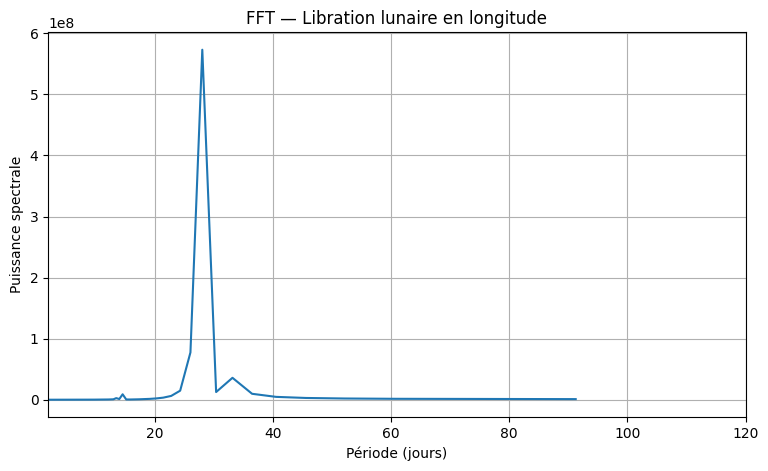

In [11]:
# Étape 11 — Analyse fréquentielle de la libration en longitude

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Série temporelle
signal_lon = df["subearth.lon"].to_numpy()

# Retrait de la moyenne
signal_lon_centered = signal_lon - np.mean(signal_lon)

# Paramètres
N = len(signal_lon_centered)
dt_heures = 1.0

# FFT réelle
fft_lon = np.fft.rfft(signal_lon_centered)
freq_h = np.fft.rfftfreq(N, d=dt_heures)

# Puissance
power_lon = np.abs(fft_lon) ** 2

# Exclure la fréquence nulle
mask_pos = freq_h > 0

freq_pos = freq_h[mask_pos]
power_pos = power_lon[mask_pos]

# Conversion fréquence -> période en jours
period_days = 1.0 / freq_pos / 24.0

# Sélection des périodes entre 2 et 120 jours
mask_period = (period_days >= 2.0) & (period_days <= 120.0)

period_sel = period_days[mask_period]
power_sel = power_pos[mask_period]

# Indices des 10 pics les plus puissants
top_idx = np.argsort(power_sel)[-10:][::-1]

top_periods = period_sel[top_idx]
top_powers = power_sel[top_idx]

fft_lon_resume = pd.DataFrame({
    "Rang": np.arange(1, 11),
    "Période_jours": top_periods,
    "Puissance": top_powers
})

display(fft_lon_resume)

print("=" * 60)
print("Période dominante longitude :", top_periods[0], "jours")
print("=" * 60)

# Figure
plt.figure(figsize=(9, 5))

plt.plot(
    period_sel,
    power_sel
)

plt.xlim(2, 120)
plt.xlabel("Période (jours)")
plt.ylabel("Puissance spectrale")
plt.title("FFT — Libration lunaire en longitude")
plt.grid(True)

plt.show()

Période FFT brute précédente : 28.076923076923077 jours
Période sur grille raffinée  : 27.652320675105486 jours
Période interpolée           : 27.6269751576204 jours
Fréquence interpolée         : 0.03619650701152378 cycles/jour


/tmp/ipykernel_1289/1483311819.py:29: RuntimeWarning: divide by zero encountered in divide
  & ((1.0 / freq_day) >= 20.0)
/tmp/ipykernel_1289/1483311819.py:30: RuntimeWarning: divide by zero encountered in divide
  & ((1.0 / freq_day) <= 40.0)


,Rang,Période_jours,Puissance_relative
0,1,27.652321,1.000000
1,2,23.339031,0.000688
2,3,21.889112,0.000072
3,4,20.647763,0.000015


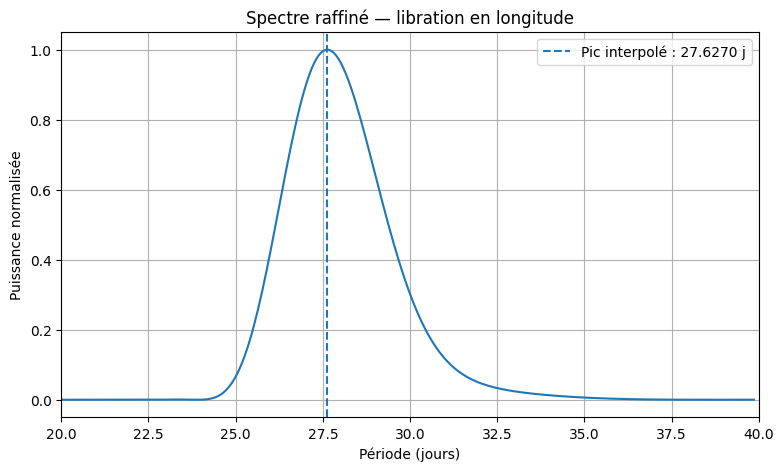

In [12]:
# Étape 12 — Raffinement de la période dominante en longitude

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend, find_peaks

signal = df["subearth.lon"].to_numpy(dtype=float)
N = len(signal)
dt_jour = 1.0 / 24.0

# 1. Retrait de la moyenne et de la tendance linéaire
signal_detrended = detrend(signal, type="linear")

# 2. Fenêtre de Hann pour réduire la fuite spectrale
window = np.hanning(N)
signal_windowed = signal_detrended * window

# 3. Zéro-padding : améliore la lecture/interpolation du spectre
n_fft = 2 ** int(np.ceil(np.log2(N * 16)))

fft_refined = np.fft.rfft(signal_windowed, n=n_fft)
freq_day = np.fft.rfftfreq(n_fft, d=dt_jour)
power_refined = np.abs(fft_refined) ** 2

# Domaine d'intérêt : périodes de 20 à 40 jours
mask = (
    (freq_day > 0)
    & ((1.0 / freq_day) >= 20.0)
    & ((1.0 / freq_day) <= 40.0)
)

freq_sel = freq_day[mask]
power_sel = power_refined[mask]

# Pic maximal
i_local = np.argmax(power_sel)
freq_peak_grid = freq_sel[i_local]

# Indice correspondant dans le spectre complet
indices_complets = np.where(mask)[0]
i_peak = indices_complets[i_local]

# 4. Interpolation parabolique sur le logarithme de la puissance
if 0 < i_peak < len(power_refined) - 1:
    y1 = np.log(power_refined[i_peak - 1] + 1e-300)
    y2 = np.log(power_refined[i_peak] + 1e-300)
    y3 = np.log(power_refined[i_peak + 1] + 1e-300)

    denom = y1 - 2.0 * y2 + y3

    if abs(denom) > 1e-15:
        delta = 0.5 * (y1 - y3) / denom
    else:
        delta = 0.0
else:
    delta = 0.0

df_freq = freq_day[1] - freq_day[0]
freq_peak_interp = freq_day[i_peak] + delta * df_freq
periode_interp = 1.0 / freq_peak_interp
periode_grid = 1.0 / freq_peak_grid

# Pics locaux principaux
peaks, _ = find_peaks(power_sel)

if len(peaks) > 0:
    ordre = peaks[np.argsort(power_sel[peaks])[::-1]]
    ordre = ordre[:5]

    tableau_pics = pd.DataFrame({
        "Rang": np.arange(1, len(ordre) + 1),
        "Période_jours": 1.0 / freq_sel[ordre],
        "Puissance_relative": power_sel[ordre] / power_sel.max()
    })
else:
    tableau_pics = pd.DataFrame()

print("=" * 65)
print("Période FFT brute précédente :", 28.076923076923077, "jours")
print("Période sur grille raffinée  :", periode_grid, "jours")
print("Période interpolée           :", periode_interp, "jours")
print("Fréquence interpolée         :", freq_peak_interp, "cycles/jour")
print("=" * 65)

display(tableau_pics)

# Figure centrée autour de la bande mensuelle
period_sel = 1.0 / freq_sel

ordre_plot = np.argsort(period_sel)

plt.figure(figsize=(9, 5))
plt.plot(
    period_sel[ordre_plot],
    power_sel[ordre_plot] / power_sel.max()
)

plt.axvline(
    periode_interp,
    linestyle="--",
    label=f"Pic interpolé : {periode_interp:.4f} j"
)

plt.xlabel("Période (jours)")
plt.ylabel("Puissance normalisée")
plt.title("Spectre raffiné — libration en longitude")
plt.xlim(20, 40)
plt.grid(True)
plt.legend()
plt.show()

Période latitude sur grille : 27.238570241064007 jours
Période latitude interpolée : 27.209301968168283 jours
Fréquence interpolée        : 0.03675213723490164 cycles/jour


,Rang,Période_jours,Puissance_relative
0,1,27.238570,1.000000
1,2,32.899598,0.001694
2,3,23.141243,0.000733
3,4,21.715043,0.000070
4,5,20.454432,0.000014


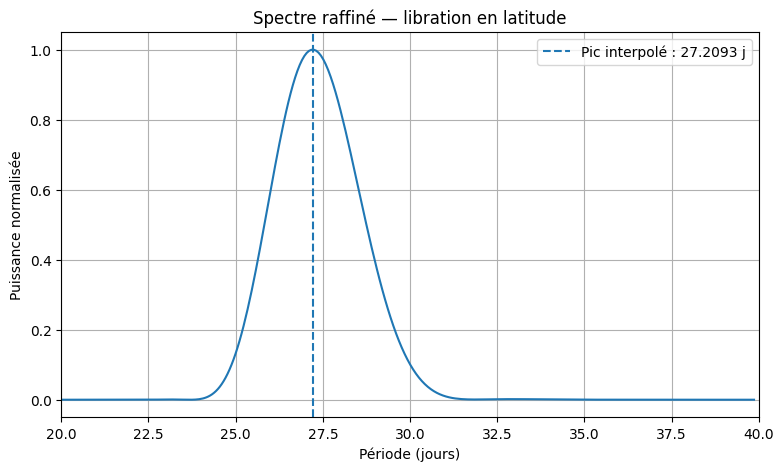

In [13]:
# Étape 13 — Raffinement de la période dominante en latitude

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import detrend, find_peaks

signal_lat = df["subearth.lat"].to_numpy(dtype=float)
N = len(signal_lat)
dt_jour = 1.0 / 24.0

# Retrait de la tendance
signal_lat_detrended = detrend(signal_lat, type="linear")

# Fenêtre de Hann
window_lat = np.hanning(N)
signal_lat_windowed = signal_lat_detrended * window_lat

# Zéro-padding
n_fft_lat = 2 ** int(np.ceil(np.log2(N * 16)))

fft_lat = np.fft.rfft(signal_lat_windowed, n=n_fft_lat)
freq_lat = np.fft.rfftfreq(n_fft_lat, d=dt_jour)
power_lat = np.abs(fft_lat) ** 2

# Éviter explicitement la fréquence nulle
freq_lat_pos = freq_lat[1:]
power_lat_pos = power_lat[1:]

period_lat_days = 1.0 / freq_lat_pos

# Domaine 20–40 jours
mask_lat = (
    (period_lat_days >= 20.0)
    & (period_lat_days <= 40.0)
)

freq_lat_sel = freq_lat_pos[mask_lat]
power_lat_sel = power_lat_pos[mask_lat]
period_lat_sel = period_lat_days[mask_lat]

# Pic principal
i_local_lat = np.argmax(power_lat_sel)
freq_peak_lat_grid = freq_lat_sel[i_local_lat]

# Indice dans le spectre complet
indices_lat_complets = np.where(
    np.isin(freq_lat, freq_lat_sel)
)[0]

i_peak_lat = indices_lat_complets[i_local_lat]

# Interpolation parabolique
if 0 < i_peak_lat < len(power_lat) - 1:
    y1 = np.log(power_lat[i_peak_lat - 1] + 1e-300)
    y2 = np.log(power_lat[i_peak_lat] + 1e-300)
    y3 = np.log(power_lat[i_peak_lat + 1] + 1e-300)

    denom = y1 - 2.0 * y2 + y3

    if abs(denom) > 1e-15:
        delta_lat = 0.5 * (y1 - y3) / denom
    else:
        delta_lat = 0.0
else:
    delta_lat = 0.0

df_freq_lat = freq_lat[1] - freq_lat[0]

freq_peak_lat_interp = (
    freq_lat[i_peak_lat] + delta_lat * df_freq_lat
)

periode_lat_grid = 1.0 / freq_peak_lat_grid
periode_lat_interp = 1.0 / freq_peak_lat_interp

# Pics secondaires
peaks_lat, _ = find_peaks(power_lat_sel)

if len(peaks_lat) > 0:
    ordre_lat = peaks_lat[
        np.argsort(power_lat_sel[peaks_lat])[::-1]
    ][:5]

    tableau_pics_lat = pd.DataFrame({
        "Rang": np.arange(1, len(ordre_lat) + 1),
        "Période_jours": period_lat_sel[ordre_lat],
        "Puissance_relative":
            power_lat_sel[ordre_lat] / power_lat_sel.max()
    })
else:
    tableau_pics_lat = pd.DataFrame()

print("=" * 65)
print("Période latitude sur grille :", periode_lat_grid, "jours")
print("Période latitude interpolée :", periode_lat_interp, "jours")
print("Fréquence interpolée        :", freq_peak_lat_interp, "cycles/jour")
print("=" * 65)

display(tableau_pics_lat)

# Figure
ordre_plot_lat = np.argsort(period_lat_sel)

plt.figure(figsize=(9, 5))

plt.plot(
    period_lat_sel[ordre_plot_lat],
    power_lat_sel[ordre_plot_lat] / power_lat_sel.max()
)

plt.axvline(
    periode_lat_interp,
    linestyle="--",
    label=f"Pic interpolé : {periode_lat_interp:.4f} j"
)

plt.xlabel("Période (jours)")
plt.ylabel("Puissance normalisée")
plt.title("Spectre raffiné — libration en latitude")
plt.xlim(20, 40)
plt.grid(True)
plt.legend()
plt.show()

In [14]:
# Étape 14 — Comparaison des périodes longitude / latitude

import pandas as pd
import numpy as np

T_lon = periode_interp
T_lat = periode_lat_interp

f_lon = freq_peak_interp
f_lat = freq_peak_lat_interp

delta_T = abs(T_lon - T_lat)
delta_f = abs(f_lon - f_lat)

T_battement_jours = 1.0 / delta_f
T_battement_ans = T_battement_jours / 365.25

comparaison_periodes = pd.DataFrame({
    "Grandeur": [
        "Période longitude (jours)",
        "Période latitude (jours)",
        "Différence de période (jours)",
        "Différence de période (heures)",
        "Fréquence longitude (cycle/jour)",
        "Fréquence latitude (cycle/jour)",
        "Différence de fréquence",
        "Période de battement (jours)",
        "Période de battement (ans)"
    ],
    "Valeur": [
        T_lon,
        T_lat,
        delta_T,
        delta_T * 24.0,
        f_lon,
        f_lat,
        delta_f,
        T_battement_jours,
        T_battement_ans
    ]
})

display(comparaison_periodes)

,Grandeur,Valeur
0,Période longitude (jours),27.626975
1,Période latitude (jours),27.209302
2,Différence de période (jours),0.417673
3,Différence de période (heures),10.024157
4,Fréquence longitude (cycle/jour),0.036197
5,Fréquence latitude (cycle/jour),0.036752
6,Différence de fréquence,0.000556
7,Période de battement (jours),1799.758109
8,Période de battement (ans),4.927469


,Rang,T_jours,C_T
0,1,27.333333,0.013351
1,2,54.583333,0.023752
2,3,81.833333,0.029820
3,4,109.125000,0.031475


Meilleure fermeture dans [20, 120] jours
T*      : 27.333333333333332 jours
C(T*)   : 0.013350769692553681


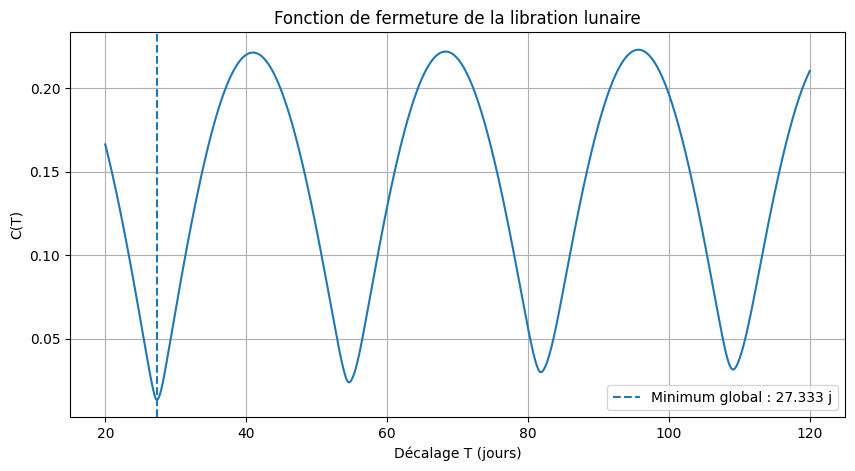

In [15]:
# Étape 15 — Fonction de fermeture C(T)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Délais testés : de 20 à 120 jours, par pas d'une heure
lag_min_h = 20 * 24
lag_max_h = 120 * 24

lags_h = np.arange(lag_min_h, lag_max_h + 1)

C_T = np.empty(len(lags_h))

for j, lag in enumerate(lags_h):
    ecarts = XYZ[lag:] - XYZ[:-lag]
    C_T[j] = np.mean(np.linalg.norm(ecarts, axis=1))

lags_days = lags_h / 24.0

# Recherche des minima locaux de C(T)
minima_idx, _ = find_peaks(-C_T)

# Classement des 10 meilleurs minima
ordre_minima = minima_idx[np.argsort(C_T[minima_idx])][:10]

fermeture_resume = pd.DataFrame({
    "Rang": np.arange(1, len(ordre_minima) + 1),
    "T_jours": lags_days[ordre_minima],
    "C_T": C_T[ordre_minima]
})

display(fermeture_resume)

# Minimum global dans la plage
i_best = np.argmin(C_T)
T_best = lags_days[i_best]
C_best = C_T[i_best]

print("=" * 65)
print("Meilleure fermeture dans [20, 120] jours")
print("T*      :", T_best, "jours")
print("C(T*)   :", C_best)
print("=" * 65)

plt.figure(figsize=(10, 5))

plt.plot(
    lags_days,
    C_T
)

plt.axvline(
    T_best,
    linestyle="--",
    label=f"Minimum global : {T_best:.3f} j"
)

plt.xlabel("Décalage T (jours)")
plt.ylabel("C(T)")
plt.title("Fonction de fermeture de la libration lunaire")
plt.grid(True)
plt.legend()
plt.show()

In [16]:
# Étape 16 — Fermeture normalisée et conversion angulaire

import numpy as np
import pandas as pd

# Distance moyenne de la trajectoire à son centre géométrique
centre = XYZ.mean(axis=0)
rayon_moyen = np.mean(np.linalg.norm(XYZ - centre, axis=1))

# Fermeture normalisée
C_best_norm = C_best / rayon_moyen

# Conversion de la corde C(T*) en angle géodésique moyen approximatif
angle_fermeture_rad = 2.0 * np.arcsin(np.clip(C_best / 2.0, 0.0, 1.0))
angle_fermeture_deg = np.rad2deg(angle_fermeture_rad)

fermeture_normalisee = pd.DataFrame({
    "Observable": [
        "T_best_days",
        "C_best",
        "rayon_moyen_trajectoire",
        "C_best_norm",
        "angle_fermeture_deg"
    ],
    "Valeur": [
        T_best,
        C_best,
        rayon_moyen,
        C_best_norm,
        angle_fermeture_deg
    ]
})

display(fermeture_normalisee)

print("=" * 60)
print("Meilleure période de fermeture :", T_best, "jours")
print("Distance résiduelle            :", C_best)
print("Fermeture normalisée           :", C_best_norm)
print("Écart angulaire équivalent     :", angle_fermeture_deg, "degrés")
print("=" * 60)

,Observable,Valeur
0,T_best_days,27.333333
1,C_best,0.013351
2,rayon_moyen_trajectoire,0.111553
3,C_best_norm,0.119681
4,angle_fermeture_deg,0.764948


Meilleure période de fermeture : 27.333333333333332 jours
Distance résiduelle            : 0.013350769692553681
Fermeture normalisée           : 0.11968074356070645
Écart angulaire équivalent     : 0.7649484378205477 degrés


In [17]:
# Étape 17 — Fermeture géodésique directe au délai optimal

import numpy as np
import pandas as pd

lag_best_h = int(round(T_best * 24.0))

X1_best = XYZ[:-lag_best_h]
X2_best = XYZ[lag_best_h:]

# Produits scalaires entre états séparés de T*
dot_best = np.sum(X1_best * X2_best, axis=1)
dot_best = np.clip(dot_best, -1.0, 1.0)

# Angles géodésiques individuels
closure_angles_deg = np.rad2deg(np.arccos(dot_best))

# Distances cordales individuelles
closure_chords = np.linalg.norm(X2_best - X1_best, axis=1)

fermeture_geodesique = pd.DataFrame({
    "Observable": [
        "lag_best_hours",
        "T_best_days",
        "closure_angle_mean_deg",
        "closure_angle_median_deg",
        "closure_angle_std_deg",
        "closure_angle_min_deg",
        "closure_angle_max_deg",
        "closure_chord_mean",
        "closure_chord_median"
    ],
    "Valeur": [
        lag_best_h,
        lag_best_h / 24.0,
        np.mean(closure_angles_deg),
        np.median(closure_angles_deg),
        np.std(closure_angles_deg, ddof=1),
        np.min(closure_angles_deg),
        np.max(closure_angles_deg),
        np.mean(closure_chords),
        np.median(closure_chords)
    ]
})

display(fermeture_geodesique)

print("=" * 65)
print("Décalage optimal utilisé       :", lag_best_h, "heures")
print("Angle moyen direct             :", closure_angles_deg.mean(), "degrés")
print("Angle médian direct            :", np.median(closure_angles_deg), "degrés")
print("Angle maximal                  :", closure_angles_deg.max(), "degrés")
print("Distance cordale moyenne       :", closure_chords.mean())
print("=" * 65)

,Observable,Valeur
0,lag_best_hours,656.000000
1,T_best_days,27.333333
2,closure_angle_mean_deg,0.764956
3,closure_angle_median_deg,0.719314
4,closure_angle_std_deg,0.468594
5,closure_angle_min_deg,0.005368
6,closure_angle_max_deg,2.279558
7,closure_chord_mean,0.013351
8,closure_chord_median,0.012554


Décalage optimal utilisé       : 656 heures
Angle moyen direct             : 0.7649555819557652 degrés
Angle médian direct            : 0.7193140782367367 degrés
Angle maximal                  : 2.2795582498645093 degrés
Distance cordale moyenne       : 0.013350769692553681


In [18]:
# Étape 18 — Tableau consolidé GVH Lunar Libration 0.1

import pandas as pd

resume_final = pd.DataFrame({
    "Observable": [
        "N_observations",
        "N_transitions",
        "Pas_temporel_heures",
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c_q95",
        "u_c_q95",
        "R_super_q95",
        "A_H_exponentiel",
        "B_H_exponentiel",
        "R2_exponentiel",
        "RMSE_exponentiel",
        "Meilleur_modele_survie",
        "u0_logistique",
        "k_logistique",
        "R2_logistique",
        "RMSE_logistique",
        "AIC_logistique",
        "theta_mean_deg",
        "theta_median_deg",
        "theta_std_deg",
        "theta_max_deg",
        "R_180",
        "T_longitude_jours",
        "T_latitude_jours",
        "Delta_T_heures",
        "T_battement_jours_estime",
        "T_best_closure_jours",
        "C_best_chord",
        "C_best_norm",
        "closure_angle_mean_deg",
        "closure_angle_median_deg",
        "closure_angle_max_deg"
    ],
    "Valeur": [
        len(df),
        len(D_T),
        1.0,
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        u_c,
        R_super,
        A_H,
        B_H,
        R2_H,
        RMSE_H,
        "Logistique",
        popt_log[0],
        popt_log[1],
        comparaison_survie.loc[
            comparaison_survie["Modèle"] == "Logistique", "R2"
        ].iloc[0],
        comparaison_survie.loc[
            comparaison_survie["Modèle"] == "Logistique", "RMSE"
        ].iloc[0],
        comparaison_survie.loc[
            comparaison_survie["Modèle"] == "Logistique", "AIC"
        ].iloc[0],
        theta_mean,
        theta_median,
        theta_std,
        theta_max,
        R_180_175,
        T_lon,
        T_lat,
        delta_T * 24.0,
        T_battement_jours,
        T_best,
        C_best,
        C_best_norm,
        closure_angles_deg.mean(),
        np.median(closure_angles_deg),
        closure_angles_deg.max()
    ]
})

display(resume_final)

,Observable,Valeur
0,N_observations,8760
1,N_transitions,8759
2,Pas_temporel_heures,1.0
3,D_T_mean,0.001076
4,S_T,0.000229
5,S_T_norm,0.212439
6,D_c_q95,0.001511
7,u_c_q95,0.817925
8,R_super_q95,0.050006
9,A_H_exponentiel,1.469222


In [19]:
# Étape 19 — Exports officiels du pipeline

from pathlib import Path
import pandas as pd
import numpy as np

dossier_sortie = Path(
    "/content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1"
)
dossier_sortie.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Résumé consolidé
# ------------------------------------------------------------

chemin_resume = dossier_sortie / (
    "GVH_Lunar_Libration_Observables_0.1.csv"
)

resume_final.to_csv(
    chemin_resume,
    index=False
)

# ------------------------------------------------------------
# 2. Série temporelle enrichie
# ------------------------------------------------------------

df_export = df.copy()

# Coordonnées sphériques
df_export["X"] = X
df_export["Y"] = Y
df_export["Z"] = Z

# D_T et angle géodésique sont déjà présents dans df
chemin_serie = dossier_sortie / (
    "GVH_Lunar_Libration_Time_Series_0.1.csv"
)

df_export.to_csv(
    chemin_serie,
    index=False
)

# ------------------------------------------------------------
# 3. Fonction de survie empirique
# ------------------------------------------------------------

survie_export = pd.DataFrame({
    "u_threshold": u_grid,
    "R_empirical": R_emp,
    "R_exponential": modele_exponentiel(
        u_grid,
        A_H,
        B_H
    ),
    "R_weibull": survie_weibull(
        u_grid,
        *popt_wei
    ),
    "R_logistic": survie_logistique(
        u_grid,
        *popt_log
    )
})

chemin_survie = dossier_sortie / (
    "GVH_Lunar_Libration_Survival_Models_0.1.csv"
)

survie_export.to_csv(
    chemin_survie,
    index=False
)

# ------------------------------------------------------------
# 4. Observables angulaires
# ------------------------------------------------------------

angles_export = pd.DataFrame({
    "theta_deg": theta_deg
})

chemin_angles = dossier_sortie / (
    "GVH_Lunar_Libration_Angles_0.1.csv"
)

angles_export.to_csv(
    chemin_angles,
    index=False
)

# ------------------------------------------------------------
# 5. Fonction de fermeture
# ------------------------------------------------------------

fermeture_export = pd.DataFrame({
    "lag_hours": lags_h,
    "lag_days": lags_days,
    "C_T": C_T
})

chemin_fermeture = dossier_sortie / (
    "GVH_Lunar_Libration_Closure_0.1.csv"
)

fermeture_export.to_csv(
    chemin_fermeture,
    index=False
)

print("=" * 70)
print("Exports terminés :")
print(chemin_resume)
print(chemin_serie)
print(chemin_survie)
print(chemin_angles)
print(chemin_fermeture)
print("=" * 70)

Exports terminés :
/content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Observables_0.1.csv
/content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Time_Series_0.1.csv
/content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Survival_Models_0.1.csv
/content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Angles_0.1.csv
/content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Closure_0.1.csv


In [20]:
# Étape 20 — Inventaire des CSV d'observables disponibles dans Drive

from pathlib import Path
import pandas as pd

racine_drive = Path("/content/drive/MyDrive")

# Motifs volontairement assez larges pour retrouver les variantes de noms
motifs = [
    "*Observables*.csv",
    "*Observable*.csv",
    "*observables*.csv",
    "*observable*.csv",
]

fichiers_trouves = set()

for motif in motifs:
    fichiers_trouves.update(racine_drive.rglob(motif))

# Exclure les dossiers et trier les chemins
fichiers_csv = sorted(
    [p for p in fichiers_trouves if p.is_file()],
    key=lambda p: str(p).lower()
)

inventaire_csv = pd.DataFrame({
    "Nom_fichier": [p.name for p in fichiers_csv],
    "Dossier": [str(p.parent) for p in fichiers_csv],
    "Chemin_complet": [str(p) for p in fichiers_csv],
    "Taille_Ko": [p.stat().st_size / 1024 for p in fichiers_csv],
})

print("=" * 80)
print("Nombre de CSV d'observables trouvés :", len(fichiers_csv))
print("=" * 80)

if fichiers_csv:
    display(inventaire_csv)

    print("\nChemins complets :")
    for i, chemin in enumerate(fichiers_csv, start=1):
        print(f"{i:02d}. {chemin}")
else:
    print("Aucun fichier CSV d'observables trouvé dans MyDrive.")

Nombre de CSV d'observables trouvés : 1


,Nom_fichier,Dossier,Chemin_complet,Taille_Ko
0,GVH_Lunar_Libration_Observables_0.1.csv,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,1.098633



Chemins complets :
01. /content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Observables_0.1.csv


In [21]:
# Étape 21 — Recherche élargie des anciens exports GVH

from pathlib import Path
import pandas as pd

racine_drive = Path("/content/drive/MyDrive")

mots_cles = [
    "gvh",
    "lorenz",
    "rossler",
    "rössler",
    "duffing",
    "cmb",
    "pantheon",
    "gravity",
    "train",
    "bao",
    "libration"
]

tous_les_csv = [
    p for p in racine_drive.rglob("*.csv")
    if p.is_file()
]

csv_gvh_possibles = []

for chemin in tous_les_csv:
    texte = str(chemin).lower()

    if any(mot in texte for mot in mots_cles):
        csv_gvh_possibles.append(chemin)

csv_gvh_possibles = sorted(
    set(csv_gvh_possibles),
    key=lambda p: str(p).lower()
)

inventaire_large = pd.DataFrame({
    "Nom_fichier": [p.name for p in csv_gvh_possibles],
    "Dossier": [str(p.parent) for p in csv_gvh_possibles],
    "Chemin_complet": [str(p) for p in csv_gvh_possibles],
    "Taille_Ko": [p.stat().st_size / 1024 for p in csv_gvh_possibles]
})

print("=" * 80)
print("Nombre de CSV GVH ou associés trouvés :", len(csv_gvh_possibles))
print("=" * 80)

if csv_gvh_possibles:
    display(inventaire_large)

    print("\nChemins complets :")
    for i, chemin in enumerate(csv_gvh_possibles, start=1):
        print(f"{i:02d}. {chemin}")
else:
    print("Aucun autre CSV associé aux pipelines GVH n'a été trouvé.")

Nombre de CSV GVH ou associés trouvés : 11


,Nom_fichier,Dossier,Chemin_complet,Taille_Ko
0,GVH_Duffing_Angles_Reproduced_0.1.csv,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,366.739258
1,GVH_Duffing_Angular_Quantiles_0.1.csv,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,0.244141
2,GVH_Lorenz_Angles_Reproduced_0.1.csv,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,180.995117
3,GVH_Lorenz_Angular_Quantiles_0.1.csv,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,0.240234
4,GVH_Rossler_Angles_Reproduced_0.1.csv,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,737.345703
5,GVH_Rossler_Angular_Quantiles_0.1.csv,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,/content/drive/MyDrive/GVH_Inter_Pipeline_Comp...,0.246094
6,GVH_Lunar_Libration_Angles_0.1.csv,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,164.276367
7,GVH_Lunar_Libration_Closure_0.1.csv,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,91.935547
8,GVH_Lunar_Libration_Observables_0.1.csv,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,1.098633
9,GVH_Lunar_Libration_Survival_Models_0.1.csv,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,/content/drive/MyDrive/GVH_Lunar_Libration_Rea...,10.906250



Chemins complets :
01. /content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Duffing_Angles_Reproduced_0.1.csv
02. /content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Duffing_Angular_Quantiles_0.1.csv
03. /content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Lorenz_Angles_Reproduced_0.1.csv
04. /content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Lorenz_Angular_Quantiles_0.1.csv
05. /content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Rossler_Angles_Reproduced_0.1.csv
06. /content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Rossler_Angular_Quantiles_0.1.csv
07. /content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Angles_0.1.csv
08. /content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Closure_0.1.csv
09. /content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Observables_0.1.csv
10. /content/drive/MyDrive/GVH_Lunar_Libration_Real_Data_0.1/GVH_Lunar_Libration_Survival_Mode

In [22]:
# Étape 22 — Rechercher les anciens notebooks GVH dans Drive

from pathlib import Path
import pandas as pd

racine_drive = Path("/content/drive/MyDrive")

mots_cles_notebooks = [
    "lorenz",
    "rossler",
    "rössler",
    "duffing",
    "cmb",
    "pantheon",
    "gravity",
    "train",
    "bao",
    "gvh"
]

notebooks = [
    p for p in racine_drive.rglob("*.ipynb")
    if p.is_file()
]

notebooks_gvh = []

for chemin in notebooks:
    texte = str(chemin).lower()

    if any(mot in texte for mot in mots_cles_notebooks):
        notebooks_gvh.append(chemin)

notebooks_gvh = sorted(
    set(notebooks_gvh),
    key=lambda p: str(p).lower()
)

inventaire_notebooks = pd.DataFrame({
    "Nom_notebook": [p.name for p in notebooks_gvh],
    "Dossier": [str(p.parent) for p in notebooks_gvh],
    "Chemin_complet": [str(p) for p in notebooks_gvh],
    "Taille_Ko": [p.stat().st_size / 1024 for p in notebooks_gvh]
})

print("=" * 80)
print("Nombre de notebooks GVH trouvés :", len(notebooks_gvh))
print("=" * 80)

if notebooks_gvh:
    display(inventaire_notebooks)

    print("\nChemins complets :")
    for i, chemin in enumerate(notebooks_gvh, start=1):
        print(f"{i:02d}. {chemin}")
else:
    print("Aucun ancien notebook GVH trouvé dans MyDrive.")

Nombre de notebooks GVH trouvés : 27


,Nom_notebook,Dossier,Chemin_complet,Taille_Ko
0,01_load_cmb_map.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/01_load...,2778.064453
1,02_pantheon_pipeline.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/02_pant...,15.563477
2,Copy of GVH_CMB_Pipeline_0.1.ipynb.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/Copy of...,1363.713867
3,Copy of GVH_NASA_Pipeline_0.1.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/Copy of...,621.233398
4,Copy of GVH_Observables_Definitions_0_1.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/Copy of...,35.767578
5,GVH Lorenz Pipeline 0.1. ipynb.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/GVH Lor...,314.119141
6,GVH_BAO_Pipeline_0.1.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/GVH_BAO...,107.294922
7,GVH_CMB_Pipeline_0.1.ipynb.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/GVH_CMB...,4172.646484
8,GVH_Coupled_Hierarchy_Test_0_1.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/GVH_Cou...,145.995117
9,GVH_Duffing_Pipeline_0.1.ipynb,/content/drive/MyDrive/Colab Notebooks,/content/drive/MyDrive/Colab Notebooks/GVH_Duf...,953.370117



Chemins complets :
01. /content/drive/MyDrive/Colab Notebooks/01_load_cmb_map.ipynb
02. /content/drive/MyDrive/Colab Notebooks/02_pantheon_pipeline.ipynb
03. /content/drive/MyDrive/Colab Notebooks/Copy of GVH_CMB_Pipeline_0.1.ipynb.ipynb
04. /content/drive/MyDrive/Colab Notebooks/Copy of GVH_NASA_Pipeline_0.1.ipynb
05. /content/drive/MyDrive/Colab Notebooks/Copy of GVH_Observables_Definitions_0_1.ipynb
06. /content/drive/MyDrive/Colab Notebooks/GVH Lorenz Pipeline 0.1. ipynb.ipynb
07. /content/drive/MyDrive/Colab Notebooks/GVH_BAO_Pipeline_0.1.ipynb
08. /content/drive/MyDrive/Colab Notebooks/GVH_CMB_Pipeline_0.1.ipynb.ipynb
09. /content/drive/MyDrive/Colab Notebooks/GVH_Coupled_Hierarchy_Test_0_1.ipynb
10. /content/drive/MyDrive/Colab Notebooks/GVH_Duffing_Pipeline_0.1.ipynb
11. /content/drive/MyDrive/Colab Notebooks/GVH_Dynamic_NASA_Pipeline_v0.1.ipynb
12. /content/drive/MyDrive/Colab Notebooks/GVH_Hierarchical_Ablation_Validation_0.1.ipynb
13. /content/drive/MyDrive/Colab Notebooks/

In [23]:
# Étape 23 — Inspection des notebooks de référence
# Objectif : repérer les cellules contenant les observables et les exports,
# sans exécuter ni modifier les notebooks.

from pathlib import Path
import json
import pandas as pd
import re

dossier_colab = Path("/content/drive/MyDrive/Colab Notebooks")

notebooks_cibles = {
    "Lorenz": dossier_colab / "GVH Lorenz Pipeline 0.1. ipynb.ipynb",
    "Rossler": dossier_colab / "GVH_Rossler_Pipeline_0.1.ipynb",
    "Duffing": dossier_colab / "GVH_Duffing_Pipeline_0.1.ipynb",
    "CMB": dossier_colab / "GVH_CMB_Pipeline_0.1.ipynb.ipynb",
    "Pantheon": dossier_colab / "GVH_Pantheon_Pipeline_0.1.ipynb",
}

mots_recherches = [
    "D_T_mean",
    "S_T_norm",
    "R_super",
    "A_H",
    "B_H",
    "theta_mean",
    "theta_max",
    "R_180",
    "Observables",
    "to_csv",
]

resultats_inspection = []

for systeme, chemin in notebooks_cibles.items():

    if not chemin.exists():
        resultats_inspection.append({
            "Système": systeme,
            "Notebook": chemin.name,
            "Existe": False,
            "Cellules_total": None,
            "Cellules_pertinentes": None,
            "Indices_cellules": None
        })
        continue

    try:
        with open(chemin, "r", encoding="utf-8") as f:
            notebook = json.load(f)

        cellules = notebook.get("cells", [])
        indices_pertinents = []

        for i, cellule in enumerate(cellules):
            source = "".join(cellule.get("source", []))

            # Inclure aussi les sorties textuelles sauvegardées
            sorties = cellule.get("outputs", [])
            texte_sorties = []

            for sortie in sorties:
                if "text" in sortie:
                    texte_sorties.append(
                        "".join(sortie.get("text", []))
                    )

                data = sortie.get("data", {})
                for cle in [
                    "text/plain",
                    "text/html",
                    "application/json"
                ]:
                    contenu = data.get(cle)

                    if isinstance(contenu, list):
                        texte_sorties.append("".join(contenu))
                    elif isinstance(contenu, str):
                        texte_sorties.append(contenu)

            texte_complet = source + "\n" + "\n".join(texte_sorties)

            if any(
                mot.lower() in texte_complet.lower()
                for mot in mots_recherches
            ):
                indices_pertinents.append(i)

        resultats_inspection.append({
            "Système": systeme,
            "Notebook": chemin.name,
            "Existe": True,
            "Cellules_total": len(cellules),
            "Cellules_pertinentes": len(indices_pertinents),
            "Indices_cellules": ", ".join(
                map(str, indices_pertinents)
            )
        })

    except Exception as erreur:
        resultats_inspection.append({
            "Système": systeme,
            "Notebook": chemin.name,
            "Existe": True,
            "Cellules_total": None,
            "Cellules_pertinentes": None,
            "Indices_cellules": f"ERREUR : {erreur}"
        })

inspection_notebooks = pd.DataFrame(resultats_inspection)

display(inspection_notebooks)

print("=" * 80)
print("Inspection terminée — aucun notebook n'a été modifié.")
print("=" * 80)

,Système,Notebook,Existe,Cellules_total,Cellules_pertinentes,Indices_cellules
0,Lorenz,GVH Lorenz Pipeline 0.1. ipynb.ipynb,True,21,14,"0, 1, 3, 5, 8, 10, 12, 13, 14, 16, 17, 18, 19, 20"
1,Rossler,GVH_Rossler_Pipeline_0.1.ipynb,True,42,19,"0, 1, 17, 19, 21, 22, 23, 25, 27, 29, 30, 31, ..."
2,Duffing,GVH_Duffing_Pipeline_0.1.ipynb,True,52,21,"1, 15, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34,..."
3,CMB,GVH_CMB_Pipeline_0.1.ipynb.ipynb,True,51,21,"0, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,..."
4,Pantheon,GVH_Pantheon_Pipeline_0.1.ipynb,True,42,16,"0, 1, 2, 25, 26, 27, 28, 29, 31, 32, 33, 35, 3..."


Inspection terminée — aucun notebook n'a été modifié.


In [24]:
# Étape 24 — Afficher les cellules pertinentes du notebook Lorenz
# Sans exécuter ni modifier le notebook

from pathlib import Path
import json

chemin_lorenz = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GVH Lorenz Pipeline 0.1. ipynb.ipynb"
)

indices_lorenz = [0, 1, 3, 5, 8, 10, 12, 13, 14, 16, 17, 18, 19, 20]

with open(chemin_lorenz, "r", encoding="utf-8") as f:
    nb_lorenz = json.load(f)

cellules_lorenz = nb_lorenz.get("cells", [])

for indice in indices_lorenz:
    cellule = cellules_lorenz[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:5000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print("".join(sortie.get("text", []))[:5000])

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:5000])

    else:
        print("\nAucune sortie enregistrée.")


CELLULE 0 | type = markdown

SOURCE :
GVH Lorenz Pipeline 0.1

1. Objectif

Ce notebook applique le cadre descriptif GVH Dynamic 0.1 au système dynamique de Lorenz.

L’objectif est de construire une chaîne de calcul reproductible permettant d’extraire, à partir d’une trajectoire tridimensionnelle du système de Lorenz, le même ensemble standardisé d’observables géométriques que celui utilisé dans les autres pipelines GVH.

La chaîne méthodologique est :

[
\text{Système de Lorenz}
;\longrightarrow;
\mathbf{X}(t)
;\longrightarrow;
D_T
;\longrightarrow;
S_T
;\longrightarrow;
D_c
;\longrightarrow;
R_{\rm super}
;\longrightarrow;
(A_H,B_H)
;\longrightarrow;
(\theta_{\rm mean},\theta_{\max},R_{180}).
]

Les observables calculées sont :

* (D_T^{mean}) : distance locale moyenne entre états successifs ;
* (S_T) : dispersion des distances locales ;
* (S_T^{norm}) : dispersion normalisée ;
* (D_c) : seuil critique défini à partir de la distribution de (D_T) ;
* (R_{\rm super}) : fraction des ét

In [25]:
# Étape 25 — Enregistrement standardisé du pipeline Lorenz

import pandas as pd

lorenz_standard = pd.DataFrame({
    "Systeme": ["Lorenz"],
    "Classe_dynamique": ["Chaotique"],
    "D_T_mean": [0.42241764442987756],
    "S_T": [0.28823770617576205],
    "S_T_norm": [0.6823524300571925],
    "D_c": [0.7106553506056397],
    "Definition_D_c": ["D_T_mean + S_T"],
    "R_super": [0.1487148714871487],
    "A_H": [1.4598455560236114],
    "B_H": [3.2494164870546776],
    "R2_exponentiel": [float("nan")],
    "RMSE_exponentiel": [float("nan")],
    "theta_mean_deg": [2.527219152822476],
    "theta_max_deg": [6.323873326481584],
    "R_180": [0.0],
    "Seuil_R_180_deg": [175.0],
    "Source_notebook": [
        "GVH Lorenz Pipeline 0.1. ipynb.ipynb"
    ],
    "Source_csv": [
        "GVH_Lorenz_Observables_0.1.csv"
    ]
})

display(lorenz_standard)

,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,D_c,Definition_D_c,R_super,A_H,B_H,R2_exponentiel,RMSE_exponentiel,theta_mean_deg,theta_max_deg,R_180,Seuil_R_180_deg,Source_notebook,Source_csv
0,Lorenz,Chaotique,0.422418,0.288238,0.682352,0.710655,D_T_mean + S_T,0.148715,1.459846,3.249416,NaN,NaN,2.527219,6.323873,0.0,175.0,GVH Lorenz Pipeline 0.1. ipynb.ipynb,GVH_Lorenz_Observables_0.1.csv


In [26]:
# Étape 26 — Afficher les cellules pertinentes du notebook Rössler
# Sans exécuter ni modifier le notebook

from pathlib import Path
import json

chemin_rossler = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GVH_Rossler_Pipeline_0.1.ipynb"
)

with open(chemin_rossler, "r", encoding="utf-8") as f:
    nb_rossler = json.load(f)

cellules_rossler = nb_rossler.get("cells", [])

mots_cibles = [
    "D_T_mean",
    "S_T_norm",
    "D_c",
    "R_super",
    "A_H",
    "B_H",
    "theta_mean",
    "theta_max",
    "R_180",
    "to_csv"
]

indices_rossler = []

for i, cellule in enumerate(cellules_rossler):
    source = "".join(cellule.get("source", []))

    sorties = cellule.get("outputs", [])
    textes_sorties = []

    for sortie in sorties:
        if "text" in sortie:
            textes_sorties.append(
                "".join(sortie.get("text", []))
            )

        data = sortie.get("data", {})

        if "text/plain" in data:
            contenu = data["text/plain"]

            if isinstance(contenu, list):
                contenu = "".join(contenu)

            textes_sorties.append(str(contenu))

    texte_complet = source + "\n" + "\n".join(textes_sorties)

    if any(
        mot.lower() in texte_complet.lower()
        for mot in mots_cibles
    ):
        indices_rossler.append(i)

print("Cellules pertinentes Rössler :", indices_rossler)

for indice in indices_rossler:
    cellule = cellules_rossler[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:5000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:5000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:5000])

    else:
        print("\nAucune sortie enregistrée.")

Cellules pertinentes Rössler : [1, 17, 19, 20, 21, 22, 23, 24, 25, 27, 29, 31, 32, 34, 36, 38, 39]

CELLULE 1 | type = markdown

SOURCE :
## 2. Objectif du pipeline

L’objectif de ce notebook est d’appliquer le cadre descriptif GVH à une trajectoire générée par le système dynamique de Rössler.

Le pipeline vise à :

- générer numériquement une trajectoire du système de Rössler ;
- supprimer le régime transitoire afin de concentrer l’analyse sur la dynamique asymptotique ;
- construire une représentation trajectorielle adaptée au calcul des observables GVH ;
- calculer un ensemble cohérent d’observables géométriques et multi-échelles :
  - \(D_T^{\mathrm{mean}}\),
  - \(S_T\),
  - \(S_T^{\mathrm{norm}}\),
  - \(D_c\),
  - \(R_{\mathrm{super}}\),
  - \(A_H\),
  - \(B_H\),
  - \(\theta_{\mathrm{mean}}\),
  - \(\theta_{\max}\),
  - \(R_{180}\) ;
- produire des figures diagnostiques permettant d’examiner la structure géométrique de la trajectoire ;
- exporter les observables et la trajectoi

In [27]:
# Étape 27 — Enregistrement standardisé du pipeline Rössler

import pandas as pd

rossler_standard = pd.DataFrame({
    "Systeme": ["Rossler"],
    "Classe_dynamique": ["Chaotique"],
    "D_T_mean": [0.086982],
    "S_T": [0.07991429],
    "S_T_norm": [0.9187461],
    "D_c": [0.1668962],
    "Definition_D_c": ["D_T_mean + S_T"],
    "R_super": [0.06480162],
    "A_H": [2.157931],
    "B_H": [22.474675],
    "R2_exponentiel": [float("nan")],
    "RMSE_exponentiel": [float("nan")],
    "theta_mean_deg": [0.721336],
    "theta_max_deg": [12.562516],
    "R_180": [0.0],
    "Seuil_R_180_deg": [170.0],
    "Source_notebook": [
        "GVH_Rossler_Pipeline_0.1.ipynb"
    ],
    "Source_csv": [
        "GVH_Rossler_Observables_0.1.csv"
    ]
})

display(rossler_standard)

,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,D_c,Definition_D_c,R_super,A_H,B_H,R2_exponentiel,RMSE_exponentiel,theta_mean_deg,theta_max_deg,R_180,Seuil_R_180_deg,Source_notebook,Source_csv
0,Rossler,Chaotique,0.086982,0.079914,0.918746,0.166896,D_T_mean + S_T,0.064802,2.157931,22.474675,NaN,NaN,0.721336,12.562516,0.0,170.0,GVH_Rossler_Pipeline_0.1.ipynb,GVH_Rossler_Observables_0.1.csv


In [28]:
# Étape 28 — Afficher les cellules pertinentes du notebook Duffing
# Sans exécuter ni modifier le notebook

from pathlib import Path
import json

chemin_duffing = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GVH_Duffing_Pipeline_0.1.ipynb"
)

with open(chemin_duffing, "r", encoding="utf-8") as f:
    nb_duffing = json.load(f)

cellules_duffing = nb_duffing.get("cells", [])

mots_cibles = [
    "D_T_mean",
    "S_T_norm",
    "D_c",
    "R_super",
    "A_H",
    "B_H",
    "theta_mean",
    "theta_max",
    "R_180",
    "to_csv"
]

indices_duffing = []

for i, cellule in enumerate(cellules_duffing):
    source = "".join(cellule.get("source", []))

    sorties = cellule.get("outputs", [])
    textes_sorties = []

    for sortie in sorties:
        if "text" in sortie:
            textes_sorties.append(
                "".join(sortie.get("text", []))
            )

        data = sortie.get("data", {})

        if "text/plain" in data:
            contenu = data["text/plain"]

            if isinstance(contenu, list):
                contenu = "".join(contenu)

            textes_sorties.append(str(contenu))

    texte_complet = source + "\n" + "\n".join(textes_sorties)

    if any(
        mot.lower() in texte_complet.lower()
        for mot in mots_cibles
    ):
        indices_duffing.append(i)

print("Cellules pertinentes Duffing :", indices_duffing)

for indice in indices_duffing:
    cellule = cellules_duffing[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:5000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:5000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:5000])

    else:
        print("\nAucune sortie enregistrée.")

Cellules pertinentes Duffing : [1, 24, 25, 26, 27, 29, 31, 32, 34, 38, 40, 41, 45, 49, 50, 51]

CELLULE 1 | type = markdown

SOURCE :
## 1. Objectif

Ce notebook applique le pipeline GVH à l’oscillateur de Duffing, un système dynamique non linéaire forcé.

L’objectif est de construire une trajectoire dynamique reproductible, puis de calculer les observables GVH suivantes :

- \(D_T\)
- \(S_T\)
- \(S_T^{\rm norm}\)
- \(D_c\)
- \(R_{\rm super}\)
- \(A_H\)
- \(B_H\)
- \(\theta_{\rm mean}\)
- \(\theta_{\max}\)
- \(R_{180}\)

Cette version 0.1 est strictement descriptive. Elle ne propose aucune interprétation Volume Partagé.

Aucune sortie enregistrée.

CELLULE 24 | type = markdown

SOURCE :
## 5. Calcul des observables GVH

Les observables GVH sont calculées à partir de la distribution de \(D_T\).

On utilise :

- \(D_T^{\rm mean}\) : moyenne de \(D_T\)
- \(S_T\) : écart-type de \(D_T\)
- \(S_T^{\rm norm} = S_T / D_T^{\rm mean}\)
- \(D_c\) : seuil critique défini par le 95e percentile de \

In [29]:
# Étape 29 — Enregistrement standardisé du pipeline Duffing

import pandas as pd

duffing_standard = pd.DataFrame({
    "Systeme": ["Duffing"],
    "Classe_dynamique": ["Non linéaire forcé"],
    "D_T_mean": [0.293183],
    "S_T": [0.203821],
    "S_T_norm": [0.695200],
    "D_c": [0.665159],
    "Definition_D_c": ["Quantile 95 %"],
    "R_super": [0.050000],
    "A_H": [1.909376],
    "B_H": [4.784771],
    "R2_exponentiel": [0.983905],
    "RMSE_exponentiel": [0.018309],
    "theta_mean_deg": [1.746517],
    "theta_max_deg": [17.910256],
    "R_180": [0.0],
    "Seuil_R_180_deg": [170.0],
    "Source_notebook": [
        "GVH_Duffing_Pipeline_0.1.ipynb"
    ],
    "Source_csv": [
        "GVH_Duffing_Observables_0.1.csv"
    ]
})

display(duffing_standard)

,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,D_c,Definition_D_c,R_super,A_H,B_H,R2_exponentiel,RMSE_exponentiel,theta_mean_deg,theta_max_deg,R_180,Seuil_R_180_deg,Source_notebook,Source_csv
0,Duffing,Non linéaire forcé,0.293183,0.203821,0.6952,0.665159,Quantile 95 %,0.05,1.909376,4.784771,0.983905,0.018309,1.746517,17.910256,0.0,170.0,GVH_Duffing_Pipeline_0.1.ipynb,GVH_Duffing_Observables_0.1.csv


In [30]:
# Étape 30 — Afficher les cellules pertinentes du notebook CMB
# Sans exécuter ni modifier le notebook

from pathlib import Path
import json

chemin_cmb = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GVH_CMB_Pipeline_0.1.ipynb.ipynb"
)

with open(chemin_cmb, "r", encoding="utf-8") as f:
    nb_cmb = json.load(f)

cellules_cmb = nb_cmb.get("cells", [])

mots_cibles = [
    "D_T_mean",
    "S_T_norm",
    "D_c",
    "R_super",
    "A_H",
    "B_H",
    "theta_mean",
    "theta_max",
    "R_180",
    "to_csv"
]

indices_cmb = []

for i, cellule in enumerate(cellules_cmb):
    source = "".join(cellule.get("source", []))

    sorties = cellule.get("outputs", [])
    textes_sorties = []

    for sortie in sorties:
        if "text" in sortie:
            textes_sorties.append(
                "".join(sortie.get("text", []))
            )

        data = sortie.get("data", {})

        if "text/plain" in data:
            contenu = data["text/plain"]

            if isinstance(contenu, list):
                contenu = "".join(contenu)

            textes_sorties.append(str(contenu))

    texte_complet = source + "\n" + "\n".join(textes_sorties)

    if any(
        mot.lower() in texte_complet.lower()
        for mot in mots_cibles
    ):
        indices_cmb.append(i)

print("Cellules pertinentes CMB :", indices_cmb)

for indice in indices_cmb:
    cellule = cellules_cmb[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:5000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:5000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:5000])

    else:
        print("\nAucune sortie enregistrée.")

Cellules pertinentes CMB : [0, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 43, 44, 45, 46, 47, 48, 49, 50]

CELLULE 0 | type = markdown

SOURCE :
## 1. Introduction

Ce notebook présente un pipeline reproductible pour appliquer les observables GVH à des cartes du fond diffus cosmologique (CMB).

L’objectif principal est de construire des quantités géométriques et statistiques directement à partir des cartes CMB, sans supposer d’interprétation physique préalable.

Les observables calculées dans ce pipeline incluent notamment :

- \(D_T = |\nabla T|\)
- \(S_T\)
- \(B_H\)
- \(R_{\rm super}\)
- \(R_{180}\)
- \(\theta_{\rm mean}\)
- \(\theta_{\max}\)

Ce notebook appartient à la série GVH Dynamic 0.1.

Aucune sortie enregistrée.

CELLULE 13 | type = markdown

SOURCE :
## 7. Régions supercritiques

On définit un seuil critique :

\[
D_c = \langle D_T \rangle + 2\sigma(D_T)
\]

Les pixels vérifiant \(D_T > D_c\) sont considérés comme supercritiques.

Aucune sortie enregistrée.

CELLULE 14 | type 

In [31]:
# Étape 31 — Enregistrement standardisé du pipeline CMB Planck

import pandas as pd

cmb_D_T_mean = 6953.060839
cmb_S_T = 4304.001060
cmb_S_T_norm = cmb_S_T / cmb_D_T_mean

cmb_standard = pd.DataFrame({
    "Systeme": ["CMB Planck"],
    "Classe_dynamique": ["Champ spatial observationnel"],
    "D_T_mean": [cmb_D_T_mean],
    "S_T": [cmb_S_T],
    "S_T_norm": [cmb_S_T_norm],
    "D_c": [15561.062959],
    "Definition_D_c": ["D_T_mean + 2 S_T"],
    "R_super": [0.035365],
    "A_H": [51.411078],
    "B_H": [4.992147e-4],
    "R2_exponentiel": [float("nan")],
    "RMSE_exponentiel": [float("nan")],
    "theta_mean_deg": [90.014622],
    "theta_max_deg": [179.999951],
    "R_180": [0.055143],
    "Seuil_R_180_deg": [170.0],
    "Definition_D_T": ["Norme du gradient spatial de température"],
    "Definition_theta": ["Orientation absolue du gradient spatial"],
    "Comparabilite_theta_trajectoire": [False],
    "Source_notebook": [
        "GVH_CMB_Pipeline_0.1.ipynb.ipynb"
    ],
    "Source_csv": [
        "GVH_CMB_Planck_results_0.1.csv"
    ]
})

display(cmb_standard)

,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,D_c,Definition_D_c,R_super,A_H,B_H,...,RMSE_exponentiel,theta_mean_deg,theta_max_deg,R_180,Seuil_R_180_deg,Definition_D_T,Definition_theta,Comparabilite_theta_trajectoire,Source_notebook,Source_csv
0,CMB Planck,Champ spatial observationnel,6953.060839,4304.00106,0.619008,15561.062959,D_T_mean + 2 S_T,0.035365,51.411078,0.000499,...,NaN,90.014622,179.999951,0.055143,170.0,Norme du gradient spatial de température,Orientation absolue du gradient spatial,False,GVH_CMB_Pipeline_0.1.ipynb.ipynb,GVH_CMB_Planck_results_0.1.csv


In [32]:
# Étape 32 — Afficher les cellules pertinentes du notebook Pantheon+
# Sans exécuter ni modifier le notebook

from pathlib import Path
import json

chemin_pantheon = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "GVH_Pantheon_Pipeline_0.1.ipynb"
)

with open(chemin_pantheon, "r", encoding="utf-8") as f:
    nb_pantheon = json.load(f)

cellules_pantheon = nb_pantheon.get("cells", [])

mots_cibles = [
    "D_T_mean",
    "S_T_norm",
    "D_c",
    "R_super",
    "A_H",
    "B_H",
    "theta_mean",
    "theta_max",
    "R_180",
    "to_csv"
]

indices_pantheon = []

for i, cellule in enumerate(cellules_pantheon):
    source = "".join(cellule.get("source", []))

    sorties = cellule.get("outputs", [])
    textes_sorties = []

    for sortie in sorties:
        if "text" in sortie:
            textes_sorties.append(
                "".join(sortie.get("text", []))
            )

        data = sortie.get("data", {})

        if "text/plain" in data:
            contenu = data["text/plain"]

            if isinstance(contenu, list):
                contenu = "".join(contenu)

            textes_sorties.append(str(contenu))

    texte_complet = source + "\n" + "\n".join(textes_sorties)

    if any(
        mot.lower() in texte_complet.lower()
        for mot in mots_cibles
    ):
        indices_pantheon.append(i)

print("Cellules pertinentes Pantheon+ :", indices_pantheon)

for indice in indices_pantheon:
    cellule = cellules_pantheon[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:5000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:5000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:5000])

    else:
        print("\nAucune sortie enregistrée.")

Cellules pertinentes Pantheon+ : [1, 6, 8, 9, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 35, 37, 38, 40]

CELLULE 1 | type = markdown

SOURCE :
## 1. Introduction

Ce notebook fait partie de la série GVH Dynamic.

Il utilise les données Pantheon+ afin de construire un ensemble d’observables géométriques :

- \(D_T\)
- \(S_T\)
- \(D_c\)
- \(R_{\rm super}\)
- \(A_H\)
- \(B_H\)
- \(\theta_{\rm mean}\)
- \(\theta_{\max}\)
- \(R_{180}\)

Ces observables sont calculées directement à partir des données disponibles, après prétraitement, sans introduire d’hypothèse issue du modèle Volume Partagé.

Aucune sortie enregistrée.

CELLULE 6 | type = code

SOURCE :
# Chemin du fichier Pantheon+
# À modifier si le fichier porte un autre nom

pantheon_file = "Pantheon+SH0ES.dat"

df = pd.read_csv(pantheon_file, sep=r"\s+", comment="#")

print("Données chargées avec succès.")
print("Nombre de lignes :", len(df))
print("Nombre de colonnes :", len(df.columns))

df.head()

SORTIES ENREGISTRÉES :

--- Sortie 1 

In [33]:
# Étape 33 — Inspecter les cellules de construction et d'export Pantheon+
# Sans exécuter ni modifier le notebook

indices_pantheon_complementaires = list(range(10, 23)) + [36, 37, 38, 39, 40, 41]

for indice in indices_pantheon_complementaires:

    if indice >= len(cellules_pantheon):
        continue

    cellule = cellules_pantheon[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:6000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:6000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:6000])

    else:
        print("\nAucune sortie enregistrée.")


CELLULE 10 | type = code

SOURCE :
df_required.describe()

SORTIES ENREGISTRÉES :

--- Sortie 1 ---
               zHD     m_b_corr  m_b_corr_err_DIAG           RA          DEC  \
count  1701.000000  1701.000000        1701.000000  1701.000000  1701.000000   
mean      0.221229    19.083629           0.240920   157.247004     6.978712   
std       0.249271     3.374499           0.098815   117.146180    26.985496   
min       0.001220     9.745710           0.111583     0.895900   -80.177600   
25%       0.027730    16.036200           0.178788    40.916900    -4.967300   
50%       0.163750    20.076300           0.217323   150.305000     0.429400   
75%       0.328680    21.824800           0.278656   243.224000    23.352800   
max       2.261370    26.929800           1.517230   359.884000    84.678300   

          IDSURVEY  
count  1701.000000  
mean     37.017637  
std      45.916840  
min       1.000000  
25%       4.000000  
50%      15.000000  
75%      57.000000  
max     15

In [34]:
# Étape 34 — Enregistrement standardisé du pipeline Pantheon+

import pandas as pd
import numpy as np

pantheon_standard = pd.DataFrame({
    "Systeme": ["Pantheon+"],
    "Classe_dynamique": ["Catalogue cosmologique observationnel"],

    "D_T_mean": [2876.4799478764703],

    # Attention : ce S_T est une dispersion locale de m_b,
    # et non l'écart-type global de D_T.
    "S_T": [0.15053638361763605],
    "S_T_norm": [np.nan],
    "Definition_S_T": [
        "Moyenne des écarts-types locaux de m_b_corr "
        "dans une fenêtre glissante de 11 points"
    ],

    "D_c": [12631.612237462954],
    "Definition_D_c": [
        "median(D_T) + 2 std(D_T)"
    ],

    "R_super": [0.06284153005464481],

    # Dans le tableau historique, A_H correspond à la moyenne
    # des valeurs supercritiques, pas à l'amplitude exponentielle.
    "A_H": [22166.616618694505],
    "Definition_A_H": [
        "mean(D_T | D_T > D_c)"
    ],

    # Amplitude réellement issue du fit exponentiel
    "A_exp_fit": [0.431367261170386],

    "B_H": [0.00017639319397018684],

    "R2_exponentiel": [np.nan],
    "RMSE_exponentiel": [np.nan],

    "theta_mean_deg": [73.21715142855119],
    "theta_max_deg": [177.3210444574389],
    "R_180": [0.004101161995898838],
    "Seuil_R_180_deg": [170.0],

    "Definition_D_T": [
        "Valeur absolue du gradient de m_b_corr "
        "par rapport au redshift zHD, après regroupement "
        "des redshifts identiques"
    ],

    "Definition_theta": [
        "Angle entre directions célestes successives "
        "du catalogue trié en redshift"
    ],

    "Comparabilite_theta_trajectoire": [False],
    "Comparabilite_S_T_norm": [False],

    "N_initial": [1701],
    "N_redshifts_uniques": [1464],

    "Source_notebook": [
        "GVH_Pantheon_Pipeline_0.1.ipynb"
    ],

    # Aucun export CSV n'a été identifié dans le notebook inspecté
    "Source_csv": [None]
})

display(pantheon_standard)

,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,Definition_S_T,D_c,Definition_D_c,R_super,A_H,...,R_180,Seuil_R_180_deg,Definition_D_T,Definition_theta,Comparabilite_theta_trajectoire,Comparabilite_S_T_norm,N_initial,N_redshifts_uniques,Source_notebook,Source_csv
0,Pantheon+,Catalogue cosmologique observationnel,2876.479948,0.150536,NaN,Moyenne des écarts-types locaux de m_b_corr da...,12631.612237,median(D_T) + 2 std(D_T),0.062842,22166.616619,...,0.004101,170.0,Valeur absolue du gradient de m_b_corr par rap...,Angle entre directions célestes successives du...,False,False,1701,1464,GVH_Pantheon_Pipeline_0.1.ipynb,None


In [35]:
# Étape 35 — Enregistrement standardisé de la libration lunaire

import pandas as pd
import numpy as np

libration_standard = pd.DataFrame({
    "Systeme": ["Libration lunaire"],
    "Classe_dynamique": ["Quasi périodique observationnelle"],

    "D_T_mean": [D_T_mean],
    "S_T": [S_T],
    "S_T_norm": [S_T_norm],

    "Definition_S_T": [
        "Écart-type global des distances sphériques horaires D_T"
    ],

    "D_c": [D_c],
    "Definition_D_c": ["Quantile 95 % de D_T"],

    "R_super": [R_super],

    # Fit exponentiel global, conservé uniquement comme diagnostic
    "A_H": [A_H],
    "Definition_A_H": [
        "Amplitude du fit exponentiel global de R(u)"
    ],

    "A_exp_fit": [A_H],
    "B_H": [B_H],

    "R2_exponentiel": [R2_H],
    "RMSE_exponentiel": [RMSE_H],

    "Meilleur_modele_survie": ["Logistique"],
    "Parametre_1_nom": ["u0"],
    "Parametre_1_valeur": [popt_log[0]],
    "Parametre_2_nom": ["k"],
    "Parametre_2_valeur": [popt_log[1]],

    "R2_meilleur_modele": [
        comparaison_survie.loc[
            comparaison_survie["Modèle"] == "Logistique",
            "R2"
        ].iloc[0]
    ],

    "RMSE_meilleur_modele": [
        comparaison_survie.loc[
            comparaison_survie["Modèle"] == "Logistique",
            "RMSE"
        ].iloc[0]
    ],

    "AIC_meilleur_modele": [
        comparaison_survie.loc[
            comparaison_survie["Modèle"] == "Logistique",
            "AIC"
        ].iloc[0]
    ],

    "theta_mean_deg": [theta_mean],
    "theta_max_deg": [theta_max],
    "R_180": [R_180_175],
    "Seuil_R_180_deg": [175.0],

    "Definition_D_T": [
        "Distance cordale entre deux vecteurs unitaires "
        "successifs représentant le point subterrestre lunaire"
    ],

    "Definition_theta": [
        "Angle entre déplacements sphériques horaires successifs"
    ],

    "Comparabilite_theta_trajectoire": [True],
    "Comparabilite_S_T_norm": [True],

    "T_longitude_jours": [T_lon],
    "T_latitude_jours": [T_lat],
    "T_best_closure_jours": [T_best],
    "C_best_norm": [C_best_norm],

    "N_initial": [len(df)],
    "N_redshifts_uniques": [np.nan],

    "Source_notebook": [
        "GVH_Lunar_Libration_Real_Data_Pipeline_0.1.ipynb"
    ],

    "Source_csv": [
        "GVH_Lunar_Libration_Observables_0.1.csv"
    ]
})

display(libration_standard)

,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,Definition_S_T,D_c,Definition_D_c,R_super,A_H,...,Comparabilite_theta_trajectoire,Comparabilite_S_T_norm,T_longitude_jours,T_latitude_jours,T_best_closure_jours,C_best_norm,N_initial,N_redshifts_uniques,Source_notebook,Source_csv
0,Libration lunaire,Quasi périodique observationnelle,0.001076,0.000229,0.212439,Écart-type global des distances sphériques hor...,0.001511,Quantile 95 % de D_T,0.050006,1.469222,...,True,True,27.626975,27.209302,27.333333,0.119681,8760,NaN,GVH_Lunar_Libration_Real_Data_Pipeline_0.1.ipynb,GVH_Lunar_Libration_Observables_0.1.csv


In [36]:
# Étape 36 — Fusion standardisée des six pipelines
# Aucun classement n'est produit à cette étape.

import pandas as pd

tables_standardisees = [
    libration_standard,
    lorenz_standard,
    rossler_standard,
    duffing_standard,
    cmb_standard,
    pantheon_standard
]

comparaison_complete = pd.concat(
    tables_standardisees,
    ignore_index=True,
    sort=False
)

# Colonnes principales affichées en premier
colonnes_principales = [
    "Systeme",
    "Classe_dynamique",
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_c",
    "Definition_D_c",
    "R_super",
    "A_H",
    "A_exp_fit",
    "B_H",
    "R2_exponentiel",
    "RMSE_exponentiel",
    "Meilleur_modele_survie",
    "R2_meilleur_modele",
    "RMSE_meilleur_modele",
    "theta_mean_deg",
    "theta_max_deg",
    "R_180",
    "Seuil_R_180_deg",
    "Comparabilite_theta_trajectoire",
    "Comparabilite_S_T_norm"
]

# Ajouter ensuite toutes les autres colonnes sans doublon
colonnes_restantes = [
    col for col in comparaison_complete.columns
    if col not in colonnes_principales
]

comparaison_complete = comparaison_complete[
    colonnes_principales + colonnes_restantes
]

print("=" * 80)
print("Nombre de systèmes :", len(comparaison_complete))
print("Nombre de colonnes :", len(comparaison_complete.columns))
print("=" * 80)

display(comparaison_complete)

Nombre de systèmes : 6
Nombre de colonnes : 39


,Systeme,Classe_dynamique,D_T_mean,S_T,S_T_norm,D_c,Definition_D_c,R_super,A_H,A_exp_fit,...,Definition_D_T,Definition_theta,T_longitude_jours,T_latitude_jours,T_best_closure_jours,C_best_norm,N_initial,N_redshifts_uniques,Source_notebook,Source_csv
0,Libration lunaire,Quasi périodique observationnelle,0.001076,0.000229,0.212439,0.001511,Quantile 95 % de D_T,0.050006,1.469222,1.469222,...,Distance cordale entre deux vecteurs unitaires...,Angle entre déplacements sphériques horaires s...,27.626975,27.209302,27.333333,0.119681,8760.0,NaN,GVH_Lunar_Libration_Real_Data_Pipeline_0.1.ipynb,GVH_Lunar_Libration_Observables_0.1.csv
1,Lorenz,Chaotique,0.422418,0.288238,0.682352,0.710655,D_T_mean + S_T,0.148715,1.459846,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GVH Lorenz Pipeline 0.1. ipynb.ipynb,GVH_Lorenz_Observables_0.1.csv
2,Rossler,Chaotique,0.086982,0.079914,0.918746,0.166896,D_T_mean + S_T,0.064802,2.157931,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GVH_Rossler_Pipeline_0.1.ipynb,GVH_Rossler_Observables_0.1.csv
3,Duffing,Non linéaire forcé,0.293183,0.203821,0.695200,0.665159,Quantile 95 %,0.050000,1.909376,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GVH_Duffing_Pipeline_0.1.ipynb,GVH_Duffing_Observables_0.1.csv
4,CMB Planck,Champ spatial observationnel,6953.060839,4304.001060,0.619008,15561.062959,D_T_mean + 2 S_T,0.035365,51.411078,NaN,...,Norme du gradient spatial de température,Orientation absolue du gradient spatial,NaN,NaN,NaN,NaN,NaN,NaN,GVH_CMB_Pipeline_0.1.ipynb.ipynb,GVH_CMB_Planck_results_0.1.csv
5,Pantheon+,Catalogue cosmologique observationnel,2876.479948,0.150536,NaN,12631.612237,median(D_T) + 2 std(D_T),0.062842,22166.616619,0.431367,...,Valeur absolue du gradient de m_b_corr par rap...,Angle entre directions célestes successives du...,NaN,NaN,NaN,NaN,1701.0,1464.0,GVH_Pantheon_Pipeline_0.1.ipynb,None


In [37]:
# Étape 37 — Tableau réduit des observables comparables
# On limite ici l'analyse aux systèmes trajectoriels.

import pandas as pd

systemes_trajectoriels = [
    "Libration lunaire",
    "Lorenz",
    "Rossler",
    "Duffing"
]

colonnes_comparables = [
    "Systeme",
    "Classe_dynamique",
    "S_T_norm",
    "theta_mean_deg",
    "theta_max_deg",
    "R_180",
    "Seuil_R_180_deg",
    "R2_exponentiel",
    "RMSE_exponentiel",
    "Meilleur_modele_survie"
]

comparaison_trajectoires = (
    comparaison_complete[
        comparaison_complete["Systeme"].isin(systemes_trajectoriels)
    ][colonnes_comparables]
    .copy()
    .reset_index(drop=True)
)

print("=" * 80)
print("Systèmes trajectoriels comparés :", len(comparaison_trajectoires))
print("=" * 80)

display(comparaison_trajectoires)

Systèmes trajectoriels comparés : 4


,Systeme,Classe_dynamique,S_T_norm,theta_mean_deg,theta_max_deg,R_180,Seuil_R_180_deg,R2_exponentiel,RMSE_exponentiel,Meilleur_modele_survie
0,Libration lunaire,Quasi périodique observationnelle,0.212439,0.709672,3.987906,0.0,175.0,0.756209,0.201322,Logistique
1,Lorenz,Chaotique,0.682352,2.527219,6.323873,0.0,175.0,NaN,NaN,NaN
2,Rossler,Chaotique,0.918746,0.721336,12.562516,0.0,170.0,NaN,NaN,NaN
3,Duffing,Non linéaire forcé,0.695200,1.746517,17.910256,0.0,170.0,0.983905,0.018309,NaN


In [38]:
# Étape 38 — Audit méthodologique de comparabilité
# Aucun recalcul n'est effectué ici.

import pandas as pd

audit_comparabilite = pd.DataFrame({
    "Systeme": [
        "Libration lunaire",
        "Lorenz",
        "Rossler",
        "Duffing"
    ],

    "Espace_etat": [
        "Sphère unité : (X, Y, Z)",
        "Espace de phase 3D : (x, y, z)",
        "Espace de phase 3D : (x, y, z)",
        "Espace de phase 2D : (x, v)"
    ],

    "Definition_D_T": [
        "||X[i+1] - X[i]||, distance cordale sphérique",
        "||X[i+1] - X[i]||",
        "||X[i+1] - X[i]||",
        "|d sqrt(x²+v²) / dt|"
    ],

    "D_T_distance_etat_successif": [
        True,
        True,
        True,
        False
    ],

    "Definition_theta": [
        "Angle entre déplacements successifs",
        "Angle entre déplacements successifs",
        "Angle entre déplacements successifs",
        "Angle entre déplacements successifs dans (x,v)"
    ],

    "Theta_structurellement_comparable": [
        True,
        True,
        True,
        True
    ],

    "S_T_norm_strictement_comparable": [
        False,
        False,
        False,
        False
    ],

    "Raison_limitation": [
        "Échelle sphérique et pas horaire propres au système",
        "Échelle des variables et pas numérique propres au système",
        "Échelle des variables, pas numérique et retrait du transitoire",
        "D_T n'est pas défini comme une distance d'état successive"
    ],

    "Action_recommandee": [
        "Conserver comme référence",
        "Recalculer après normalisation de l'espace d'état et du pas",
        "Recalculer après normalisation de l'espace d'état et du pas",
        "Recalculer D_T à partir de ||(x,v)[i+1]-(x,v)[i]||"
    ]
})

display(audit_comparabilite)

,Systeme,Espace_etat,Definition_D_T,D_T_distance_etat_successif,Definition_theta,Theta_structurellement_comparable,S_T_norm_strictement_comparable,Raison_limitation,Action_recommandee
0,Libration lunaire,"Sphère unité : (X, Y, Z)","||X[i+1] - X[i]||, distance cordale sphérique",True,Angle entre déplacements successifs,True,False,Échelle sphérique et pas horaire propres au sy...,Conserver comme référence
1,Lorenz,"Espace de phase 3D : (x, y, z)",||X[i+1] - X[i]||,True,Angle entre déplacements successifs,True,False,Échelle des variables et pas numérique propres...,Recalculer après normalisation de l'espace d'é...
2,Rossler,"Espace de phase 3D : (x, y, z)",||X[i+1] - X[i]||,True,Angle entre déplacements successifs,True,False,"Échelle des variables, pas numérique et retrai...",Recalculer après normalisation de l'espace d'é...
3,Duffing,"Espace de phase 2D : (x, v)",|d sqrt(x²+v²) / dt|,False,"Angle entre déplacements successifs dans (x,v)",True,False,D_T n'est pas défini comme une distance d'état...,"Recalculer D_T à partir de ||(x,v)[i+1]-(x,v)[..."


,Systeme,Classe_dynamique,theta_mean_deg,theta_max_deg,R_180,Seuil_R_180_deg,Rapport_theta_max_mean
0,Libration lunaire,Quasi périodique observationnelle,0.709672,3.987906,0.0,175.0,5.619362
1,Lorenz,Chaotique,2.527219,6.323873,0.0,175.0,2.502305
2,Rossler,Chaotique,0.721336,12.562516,0.0,170.0,17.415623
3,Duffing,Non linéaire forcé,1.746517,17.910256,0.0,170.0,10.254842


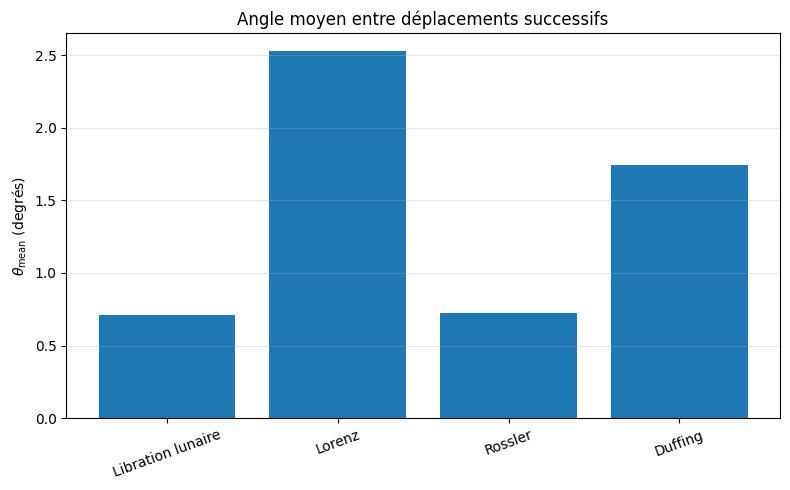

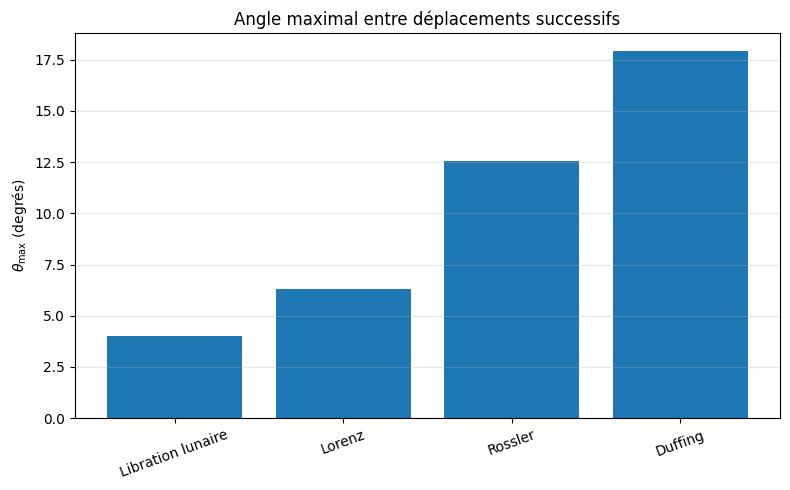

In [39]:
# Étape 39 — Comparaison descriptive des angles trajectoriels
# Attention : les valeurs dépendent du pas d'échantillonnage.

import pandas as pd
import matplotlib.pyplot as plt

comparaison_angles = comparaison_trajectoires[
    [
        "Systeme",
        "Classe_dynamique",
        "theta_mean_deg",
        "theta_max_deg",
        "R_180",
        "Seuil_R_180_deg"
    ]
].copy()

comparaison_angles["Rapport_theta_max_mean"] = (
    comparaison_angles["theta_max_deg"]
    / comparaison_angles["theta_mean_deg"]
)

display(comparaison_angles)

# Figure 1 — angle moyen
plt.figure(figsize=(8, 5))

plt.bar(
    comparaison_angles["Systeme"],
    comparaison_angles["theta_mean_deg"]
)

plt.ylabel(r"$\theta_{\mathrm{mean}}$ (degrés)")
plt.title("Angle moyen entre déplacements successifs")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2 — angle maximal
plt.figure(figsize=(8, 5))

plt.bar(
    comparaison_angles["Systeme"],
    comparaison_angles["theta_max_deg"]
)

plt.ylabel(r"$\theta_{\max}$ (degrés)")
plt.title("Angle maximal entre déplacements successifs")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Étape 40 — Vérifier si les séries angulaires complètes
# sont enregistrées dans les notebooks historiques

import json
from pathlib import Path
import pandas as pd

notebooks_angles = {
    "Lorenz": Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "GVH Lorenz Pipeline 0.1. ipynb.ipynb"
    ),
    "Rossler": Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "GVH_Rossler_Pipeline_0.1.ipynb"
    ),
    "Duffing": Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "GVH_Duffing_Pipeline_0.1.ipynb"
    )
}

recherche_angles = []

for systeme, chemin in notebooks_angles.items():

    with open(chemin, "r", encoding="utf-8") as f:
        nb = json.load(f)

    cellules = nb.get("cells", [])

    indices = []
    noms_variables = []

    for i, cellule in enumerate(cellules):
        source = "".join(cellule.get("source", []))

        termes = [
            "theta =",
            "theta_deg =",
            "theta_rad =",
            "np.save",
            "to_csv",
            "Angles"
        ]

        if any(terme.lower() in source.lower() for terme in termes):
            indices.append(i)

            for variable in [
                "theta",
                "theta_deg",
                "theta_rad"
            ]:
                if variable in source:
                    noms_variables.append(variable)

    recherche_angles.append({
        "Systeme": systeme,
        "Indices_cellules": ", ".join(map(str, indices)),
        "Variables_reperees": ", ".join(sorted(set(noms_variables))),
        "Notebook": chemin.name
    })

audit_series_angles = pd.DataFrame(recherche_angles)

display(audit_series_angles)

,Systeme,Indices_cellules,Variables_reperees,Notebook
0,Lorenz,"15, 16, 18, 19",theta,GVH Lorenz Pipeline 0.1. ipynb.ipynb
1,Rossler,"26, 27, 29, 35, 36, 38","theta, theta_deg, theta_rad",GVH_Rossler_Pipeline_0.1.ipynb
2,Duffing,"28, 29, 35, 36, 45",theta,GVH_Duffing_Pipeline_0.1.ipynb


In [41]:
# Étape 41 — Rechercher des séries angulaires complètes
# dans les sorties enregistrées des notebooks historiques

import json
from pathlib import Path
import pandas as pd
import re

notebooks_angles = {
    "Lorenz": Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "GVH Lorenz Pipeline 0.1. ipynb.ipynb"
    ),
    "Rossler": Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "GVH_Rossler_Pipeline_0.1.ipynb"
    ),
    "Duffing": Path(
        "/content/drive/MyDrive/Colab Notebooks/"
        "GVH_Duffing_Pipeline_0.1.ipynb"
    )
}

resultats_series = []

for systeme, chemin in notebooks_angles.items():

    with open(chemin, "r", encoding="utf-8") as f:
        nb = json.load(f)

    cellules = nb.get("cells", [])

    sorties_candidates = []
    longueur_max_texte = 0
    presence_array_long = False
    cellules_candidates = []

    for i, cellule in enumerate(cellules):
        sorties = cellule.get("outputs", [])

        for sortie in sorties:
            morceaux = []

            if "text" in sortie:
                morceaux.append("".join(sortie.get("text", [])))

            data = sortie.get("data", {})

            for cle in ["text/plain", "application/json"]:
                contenu = data.get(cle)

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                if contenu is not None:
                    morceaux.append(str(contenu))

            texte = "\n".join(morceaux)

            if not texte:
                continue

            longueur_max_texte = max(longueur_max_texte, len(texte))

            # Indices simples qu'une longue série numérique
            # pourrait être réellement enregistrée
            nombres = re.findall(
                r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?",
                texte
            )

            if (
                len(nombres) >= 100
                and (
                    "array(" in texte.lower()
                    or "[" in texte
                )
            ):
                presence_array_long = True
                cellules_candidates.append(i)

            if any(
                mot in texte.lower()
                for mot in ["theta", "angle", "array("]
            ):
                sorties_candidates.append((i, len(nombres), len(texte)))

    resultats_series.append({
        "Systeme": systeme,
        "Serie_complete_probablement_sauvegardee": presence_array_long,
        "Cellules_candidates": ", ".join(
            map(str, sorted(set(cellules_candidates)))
        ),
        "Longueur_max_sortie_texte": longueur_max_texte,
        "Nombre_sorties_candidates": len(sorties_candidates),
        "Notebook": chemin.name
    })

audit_sorties_angles = pd.DataFrame(resultats_series)

display(audit_sorties_angles)

,Systeme,Serie_complete_probablement_sauvegardee,Cellules_candidates,Longueur_max_sortie_texte,Nombre_sorties_candidates,Notebook
0,Lorenz,False,,263,4,GVH Lorenz Pipeline 0.1. ipynb.ipynb
1,Rossler,False,,274,3,GVH_Rossler_Pipeline_0.1.ipynb
2,Duffing,False,,577,3,GVH_Duffing_Pipeline_0.1.ipynb


In [42]:
# Étape 42 — Extraire la configuration numérique historique de Lorenz
# Le notebook n'est ni exécuté ni modifié.

indices_configuration_lorenz = [2, 4, 6, 7]

for indice in indices_configuration_lorenz:

    if indice >= len(cellules_lorenz):
        continue

    cellule = cellules_lorenz[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:8000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:8000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:8000])

    else:
        print("\nAucune sortie enregistrée.")


CELLULE 2 | type = code

SOURCE :
# ============================================================
# GVH_Lorenz_Pipeline_0.1
# Étape 2 — Imports Python
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

Aucune sortie enregistrée.

CELLULE 4 | type = code

SOURCE :
# ============================================================
# Étape 3 — Génération de la trajectoire de Lorenz
# ============================================================

# Paramètres classiques du système de Lorenz
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

# Définition du système de Lorenz
def lorenz_system(t, state, sigma, rho, beta):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return [dxdt, dydt, dzdt]

# Conditions initiales
initial_state = [1.0, 1.0, 1.0]

# Intervalle temporel
t_start = 0.0


In [43]:
# Étape 43 — Reproduction historique de Lorenz
# puis calcul des quantiles angulaires robustes

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# 1. Paramètres historiques
# ------------------------------------------------------------

sigma_l = 10.0
rho_l = 28.0
beta_l = 8.0 / 3.0

initial_state_l = [1.0, 1.0, 1.0]

t_start_l = 0.0
t_end_l = 50.0
n_points_l = 10000

t_eval_l = np.linspace(
    t_start_l,
    t_end_l,
    n_points_l
)

def lorenz_system_repro(t, state, sigma, rho, beta):
    x, y, z = state

    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ]

# ------------------------------------------------------------
# 2. Intégration
# ------------------------------------------------------------

solution_l = solve_ivp(
    fun=lorenz_system_repro,
    t_span=(t_start_l, t_end_l),
    y0=initial_state_l,
    t_eval=t_eval_l,
    args=(sigma_l, rho_l, beta_l),
    rtol=1e-9,
    atol=1e-12
)

if not solution_l.success:
    raise RuntimeError(
        f"Échec de l'intégration Lorenz : {solution_l.message}"
    )

X_l = solution_l.y.T

# ------------------------------------------------------------
# 3. D_T historique
# ------------------------------------------------------------

dX_l = np.diff(X_l, axis=0)
D_T_l = np.linalg.norm(dX_l, axis=1)

D_T_mean_l = np.mean(D_T_l)
S_T_l = np.std(D_T_l)
S_T_norm_l = S_T_l / D_T_mean_l

# ------------------------------------------------------------
# 4. Angles historiques
# ------------------------------------------------------------

v1_l = dX_l[:-1]
v2_l = dX_l[1:]

n1_l = np.linalg.norm(v1_l, axis=1)
n2_l = np.linalg.norm(v2_l, axis=1)

valid_l = (n1_l > 0) & (n2_l > 0)

cos_theta_l = np.sum(
    v1_l[valid_l] * v2_l[valid_l],
    axis=1
) / (
    n1_l[valid_l] * n2_l[valid_l]
)

cos_theta_l = np.clip(cos_theta_l, -1.0, 1.0)

theta_l_deg = np.rad2deg(
    np.arccos(cos_theta_l)
)

# ------------------------------------------------------------
# 5. Contrôle de reproduction
# ------------------------------------------------------------

references_lorenz = {
    "D_T_mean": 0.42241764442987756,
    "S_T": 0.28823770617576205,
    "S_T_norm": 0.6823524300571925,
    "theta_mean": 2.527219152822476,
    "theta_max": 6.323873326481584
}

reproduction_lorenz = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "theta_mean",
        "theta_max"
    ],
    "Historique": [
        references_lorenz["D_T_mean"],
        references_lorenz["S_T"],
        references_lorenz["S_T_norm"],
        references_lorenz["theta_mean"],
        references_lorenz["theta_max"]
    ],
    "Reproduit": [
        D_T_mean_l,
        S_T_l,
        S_T_norm_l,
        np.mean(theta_l_deg),
        np.max(theta_l_deg)
    ]
})

reproduction_lorenz["Erreur_absolue"] = np.abs(
    reproduction_lorenz["Reproduit"]
    - reproduction_lorenz["Historique"]
)

display(reproduction_lorenz)

# ------------------------------------------------------------
# 6. Quantiles angulaires robustes
# ------------------------------------------------------------

quantiles_lorenz = pd.DataFrame({
    "Observable": [
        "theta_min",
        "theta_q50",
        "theta_q90",
        "theta_q95",
        "theta_q99",
        "theta_mean",
        "theta_std",
        "theta_max"
    ],
    "Valeur": [
        np.min(theta_l_deg),
        np.quantile(theta_l_deg, 0.50),
        np.quantile(theta_l_deg, 0.90),
        np.quantile(theta_l_deg, 0.95),
        np.quantile(theta_l_deg, 0.99),
        np.mean(theta_l_deg),
        np.std(theta_l_deg, ddof=1),
        np.max(theta_l_deg)
    ]
})

display(quantiles_lorenz)

print("=" * 70)
print("Nombre d'angles Lorenz :", len(theta_l_deg))
print("Erreur max reproduction :",
      reproduction_lorenz["Erreur_absolue"].max())
print("=" * 70)

,Observable,Historique,Reproduit,Erreur_absolue
0,D_T_mean,0.422418,0.422418,0.0
1,S_T,0.288238,0.288238,0.0
2,S_T_norm,0.682352,0.682352,0.0
3,theta_mean,2.527219,2.527219,0.0
4,theta_max,6.323873,6.323873,0.0


,Observable,Valeur
0,theta_min,0.076331
1,theta_q50,2.440511
2,theta_q90,4.242728
3,theta_q95,4.730453
4,theta_q99,5.384646
5,theta_mean,2.527219
6,theta_std,1.157333
7,theta_max,6.323873


Nombre d'angles Lorenz : 9998
Erreur max reproduction : 0.0


In [44]:
# Étape 44 — Export officiel des angles Lorenz reproduits

from pathlib import Path
import pandas as pd

dossier_comparaison = Path(
    "/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1"
)
dossier_comparaison.mkdir(parents=True, exist_ok=True)

lorenz_angles_export = pd.DataFrame({
    "theta_deg": theta_l_deg
})

chemin_angles_lorenz = (
    dossier_comparaison
    / "GVH_Lorenz_Angles_Reproduced_0.1.csv"
)

chemin_quantiles_lorenz = (
    dossier_comparaison
    / "GVH_Lorenz_Angular_Quantiles_0.1.csv"
)

lorenz_angles_export.to_csv(
    chemin_angles_lorenz,
    index=False
)

quantiles_lorenz.to_csv(
    chemin_quantiles_lorenz,
    index=False
)

print("=" * 70)
print("Exports Lorenz terminés :")
print(chemin_angles_lorenz)
print(chemin_quantiles_lorenz)
print("=" * 70)

Exports Lorenz terminés :
/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Lorenz_Angles_Reproduced_0.1.csv
/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Lorenz_Angular_Quantiles_0.1.csv


In [45]:
# Étape 45 — Extraire la configuration numérique historique de Rössler
# Le notebook n'est ni exécuté ni modifié.

indices_configuration_rossler = list(range(2, 17))

for indice in indices_configuration_rossler:

    if indice >= len(cellules_rossler):
        continue

    cellule = cellules_rossler[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:8000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:8000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:8000])

    else:
        print("\nAucune sortie enregistrée.")


CELLULE 2 | type = markdown

SOURCE :
 3. Imports Python.

Aucune sortie enregistrée.

CELLULE 3 | type = code

SOURCE :
# ============================================================
# 3. Imports Python
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# Reproductibilité
SEED = 42
np.random.seed(SEED)

# Affichage numérique
np.set_printoptions(
    precision=6,
    suppress=True
)

# Affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 6)

print("Imports chargés avec succès.")
print(f"Seed de reproductibilité : {SEED}")

SORTIES ENREGISTRÉES :

--- Sortie 1 ---
Imports chargés avec succès.
Seed de reproductibilité : 42


CELLULE 4 | type = markdown

SOURCE :
cellule 4 — Paramètres du système de Rössler.

Aucune sortie enregistrée.

CELLULE 5 | type = code

SOURCE :
# ================

In [46]:
# Étape 46 — Reproduction historique de Rössler
# puis calcul des quantiles angulaires robustes

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# 1. Paramètres historiques
# ------------------------------------------------------------

a_r = 0.2
b_r = 0.2
c_r = 5.7

y0_r = np.array([1.0, 0.0, 0.0])

t_min_r = 0.0
t_max_r = 500.0
n_points_r = 50000

t_eval_r = np.linspace(
    t_min_r,
    t_max_r,
    n_points_r
)

def rossler_system_repro(t, state, a, b, c):
    x, y, z = state

    return [
        -y - z,
        x + a * y,
        b + z * (x - c)
    ]

# ------------------------------------------------------------
# 2. Intégration
# ------------------------------------------------------------

solution_r = solve_ivp(
    fun=lambda t, state: rossler_system_repro(
        t, state, a_r, b_r, c_r
    ),
    t_span=(t_min_r, t_max_r),
    y0=y0_r,
    t_eval=t_eval_r,
    method="RK45",
    rtol=1e-9,
    atol=1e-12
)

if not solution_r.success:
    raise RuntimeError(
        f"Échec de l'intégration Rössler : {solution_r.message}"
    )

trajectory_r = solution_r.y.T

# ------------------------------------------------------------
# 3. Suppression du transitoire
# ------------------------------------------------------------

transient_fraction_r = 0.20
transient_index_r = int(
    transient_fraction_r * len(trajectory_r)
)

trajectory_r_gvh = trajectory_r[transient_index_r:]

# ------------------------------------------------------------
# 4. D_T historique
# ------------------------------------------------------------

increments_r = np.diff(
    trajectory_r_gvh,
    axis=0
)

D_T_r = np.linalg.norm(
    increments_r,
    axis=1
)

D_T_mean_r = np.mean(D_T_r)
S_T_r = np.std(D_T_r)
S_T_norm_r = S_T_r / D_T_mean_r

# ------------------------------------------------------------
# 5. Angles historiques
# ------------------------------------------------------------

v1_r = increments_r[:-1]
v2_r = increments_r[1:]

n1_r = np.linalg.norm(v1_r, axis=1)
n2_r = np.linalg.norm(v2_r, axis=1)

valid_r = (n1_r > 0) & (n2_r > 0)

cos_theta_r = np.sum(
    v1_r[valid_r] * v2_r[valid_r],
    axis=1
) / (
    n1_r[valid_r] * n2_r[valid_r]
)

cos_theta_r = np.clip(
    cos_theta_r,
    -1.0,
    1.0
)

theta_r_deg = np.rad2deg(
    np.arccos(cos_theta_r)
)

# ------------------------------------------------------------
# 6. Contrôle de reproduction
# ------------------------------------------------------------

references_rossler = {
    "D_T_mean": 0.08698191,
    "S_T": 0.07991429,
    "S_T_norm": 0.9187461,
    "theta_mean": 0.721336,
    "theta_max": 12.562516
}

reproduction_rossler = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "theta_mean",
        "theta_max"
    ],
    "Historique": [
        references_rossler["D_T_mean"],
        references_rossler["S_T"],
        references_rossler["S_T_norm"],
        references_rossler["theta_mean"],
        references_rossler["theta_max"]
    ],
    "Reproduit": [
        D_T_mean_r,
        S_T_r,
        S_T_norm_r,
        np.mean(theta_r_deg),
        np.max(theta_r_deg)
    ]
})

reproduction_rossler["Erreur_absolue"] = np.abs(
    reproduction_rossler["Reproduit"]
    - reproduction_rossler["Historique"]
)

display(reproduction_rossler)

# ------------------------------------------------------------
# 7. Quantiles angulaires robustes
# ------------------------------------------------------------

quantiles_rossler = pd.DataFrame({
    "Observable": [
        "theta_min",
        "theta_q50",
        "theta_q90",
        "theta_q95",
        "theta_q99",
        "theta_mean",
        "theta_std",
        "theta_max"
    ],
    "Valeur": [
        np.min(theta_r_deg),
        np.quantile(theta_r_deg, 0.50),
        np.quantile(theta_r_deg, 0.90),
        np.quantile(theta_r_deg, 0.95),
        np.quantile(theta_r_deg, 0.99),
        np.mean(theta_r_deg),
        np.std(theta_r_deg, ddof=1),
        np.max(theta_r_deg)
    ]
})

display(quantiles_rossler)

print("=" * 70)
print("Nombre d'angles Rössler :", len(theta_r_deg))
print(
    "Erreur max reproduction :",
    reproduction_rossler["Erreur_absolue"].max()
)
print("=" * 70)

,Observable,Historique,Reproduit,Erreur_absolue
0,D_T_mean,0.086982,0.086982,2.260260e-09
1,S_T,0.079914,0.079914,1.620007e-09
2,S_T_norm,0.918746,0.918746,3.579551e-08
3,theta_mean,0.721336,0.721336,1.943306e-07
4,theta_max,12.562516,12.562516,4.481679e-07


,Observable,Valeur
0,theta_min,0.093401
1,theta_q50,0.591281
2,theta_q90,0.904591
3,theta_q95,1.436653
4,theta_q99,3.340713
5,theta_mean,0.721336
6,theta_std,0.713808
7,theta_max,12.562516


Nombre d'angles Rössler : 39998
Erreur max reproduction : 4.4816785305101803e-07


In [47]:
# Étape 47 — Export officiel des angles Rössler reproduits

from pathlib import Path
import pandas as pd

dossier_comparaison = Path(
    "/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1"
)
dossier_comparaison.mkdir(parents=True, exist_ok=True)

rossler_angles_export = pd.DataFrame({
    "theta_deg": theta_r_deg
})

chemin_angles_rossler = (
    dossier_comparaison
    / "GVH_Rossler_Angles_Reproduced_0.1.csv"
)

chemin_quantiles_rossler = (
    dossier_comparaison
    / "GVH_Rossler_Angular_Quantiles_0.1.csv"
)

rossler_angles_export.to_csv(
    chemin_angles_rossler,
    index=False
)

quantiles_rossler.to_csv(
    chemin_quantiles_rossler,
    index=False
)

print("=" * 70)
print("Exports Rössler terminés :")
print(chemin_angles_rossler)
print(chemin_quantiles_rossler)
print("=" * 70)

Exports Rössler terminés :
/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Rossler_Angles_Reproduced_0.1.csv
/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Rossler_Angular_Quantiles_0.1.csv


In [48]:
# Étape 48 — Extraire la configuration numérique historique de Duffing
# Le notebook n'est ni exécuté ni modifié.

indices_configuration_duffing = list(range(2, 24))

for indice in indices_configuration_duffing:

    if indice >= len(cellules_duffing):
        continue

    cellule = cellules_duffing[indice]

    print("\n" + "=" * 90)
    print(
        f"CELLULE {indice} | "
        f"type = {cellule.get('cell_type', 'inconnu')}"
    )
    print("=" * 90)

    source = "".join(cellule.get("source", []))

    print("\nSOURCE :")
    print(source[:8000])

    sorties = cellule.get("outputs", [])

    if sorties:
        print("\nSORTIES ENREGISTRÉES :")

        for j, sortie in enumerate(sorties, start=1):
            print(f"\n--- Sortie {j} ---")

            if "text" in sortie:
                print(
                    "".join(
                        sortie.get("text", [])
                    )[:8000]
                )

            data = sortie.get("data", {})

            if "text/plain" in data:
                contenu = data["text/plain"]

                if isinstance(contenu, list):
                    contenu = "".join(contenu)

                print(str(contenu)[:8000])

    else:
        print("\nAucune sortie enregistrée.")


CELLULE 2 | type = code

SOURCE :
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

import sys
import scipy

Aucune sortie enregistrée.

CELLULE 3 | type = markdown

SOURCE :
## 2. Définition du système de Duffing

On considère l’oscillateur de Duffing forcé :

\[
\ddot{x} + \delta \dot{x} + \alpha x + \beta x^3 = \gamma \cos(\omega t)
\]

En posant \(v = \dot{x}\), le système devient :

\[
\dot{x} = v
\]

\[
\dot{v} = -\delta v - \alpha x - \beta x^3 + \gamma \cos(\omega t)
\]

Les paramètres utilisés ici correspondent à un régime non linéaire forcé permettant de produire une dynamique riche.

Aucune sortie enregistrée.

CELLULE 4 | type = code

SOURCE :
# Paramètres du système de Duffing
delta = 0.2
alpha = -1.0
beta = 1.0
gamma = 0.3
omega = 1.2

# Conditions initiales
x0 = 0.1
v0 = 0.0
y0 = [x0, v0]

# Domaine temporel
t_min = 0.0
t_max = 500.0
n_time = 20000

t_eval = np.linspace(t_m

In [50]:
# Étape 49 — Reproduction historique de Duffing
# puis calcul des quantiles angulaires robustes

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# 1. Paramètres historiques
# ------------------------------------------------------------

delta_d = 0.2
alpha_d = -1.0
beta_d = 1.0
gamma_d = 0.3
omega_d = 1.2

x0_d = 0.1
v0_d = 0.0
y0_d = [x0_d, v0_d]

t_min_d = 0.0
t_max_d = 500.0
n_time_d = 20000

t_eval_d = np.linspace(
    t_min_d,
    t_max_d,
    n_time_d
)

def duffing_system_repro(
    t,
    y,
    delta,
    alpha,
    beta,
    gamma,
    omega
):
    x, v = y

    dxdt = v
    dvdt = (
        -delta * v
        - alpha * x
        - beta * x**3
        + gamma * np.cos(omega * t)
    )

    return [dxdt, dvdt]

# ------------------------------------------------------------
# 2. Intégration numérique
# ------------------------------------------------------------

solution_d = solve_ivp(
    fun=lambda t, y: duffing_system_repro(
        t,
        y,
        delta_d,
        alpha_d,
        beta_d,
        gamma_d,
        omega_d
    ),
    t_span=(t_min_d, t_max_d),
    y0=y0_d,
    t_eval=t_eval_d,
    method="RK45",
    rtol=1e-9,
    atol=1e-12
)

if not solution_d.success:
    raise RuntimeError(
        f"Échec de l'intégration Duffing : {solution_d.message}"
    )

t_d = solution_d.t
x_d = solution_d.y[0]
v_d = solution_d.y[1]

# ------------------------------------------------------------
# 3. D_T historique
# ------------------------------------------------------------

T_d = np.sqrt(x_d**2 + v_d**2)
D_T_d = np.abs(np.gradient(T_d, t_d))

D_T_mean_d = np.mean(D_T_d)
S_T_d = np.std(D_T_d)
S_T_norm_d = S_T_d / D_T_mean_d

# ------------------------------------------------------------
# 4. Angles historiques dans l'espace (x, v)
# ------------------------------------------------------------

trajectory_d = np.column_stack([
    x_d,
    v_d
])

u_d = trajectory_d[1:-1] - trajectory_d[:-2]
w_d = trajectory_d[2:] - trajectory_d[1:-1]

norm_u_d = np.linalg.norm(u_d, axis=1)
norm_w_d = np.linalg.norm(w_d, axis=1)

valid_d = (
    (norm_u_d > 0)
    & (norm_w_d > 0)
)

cos_theta_d = np.sum(
    u_d[valid_d] * w_d[valid_d],
    axis=1
) / (
    norm_u_d[valid_d] * norm_w_d[valid_d]
)

cos_theta_d = np.clip(
    cos_theta_d,
    -1.0,
    1.0
)

theta_d_deg = np.rad2deg(
    np.arccos(cos_theta_d)
)

# ------------------------------------------------------------
# 5. Contrôle de reproduction
# ------------------------------------------------------------

references_duffing = {
    "D_T_mean": 0.293183,
    "S_T": 0.203821,
    "S_T_norm": 0.695200,
    "theta_mean": 1.746517,
    "theta_max": 17.910256
}

reproduction_duffing = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "theta_mean",
        "theta_max"
    ],
    "Historique": [
        references_duffing["D_T_mean"],
        references_duffing["S_T"],
        references_duffing["S_T_norm"],
        references_duffing["theta_mean"],
        references_duffing["theta_max"]
    ],
    "Reproduit": [
        D_T_mean_d,
        S_T_d,
        S_T_norm_d,
        np.mean(theta_d_deg),
        np.max(theta_d_deg)
    ]
})

reproduction_duffing["Erreur_absolue"] = np.abs(
    reproduction_duffing["Reproduit"]
    - reproduction_duffing["Historique"]
)

display(reproduction_duffing)

# ------------------------------------------------------------
# 6. Quantiles angulaires robustes
# ------------------------------------------------------------

quantiles_duffing = pd.DataFrame({
    "Observable": [
        "theta_min",
        "theta_q50",
        "theta_q90",
        "theta_q95",
        "theta_q99",
        "theta_mean",
        "theta_std",
        "theta_max"
    ],
    "Valeur": [
        np.min(theta_d_deg),
        np.quantile(theta_d_deg, 0.50),
        np.quantile(theta_d_deg, 0.90),
        np.quantile(theta_d_deg, 0.95),
        np.quantile(theta_d_deg, 0.99),
        np.mean(theta_d_deg),
        np.std(theta_d_deg, ddof=1),
        np.max(theta_d_deg)
    ]
})

display(quantiles_duffing)

print("=" * 70)
print("Nombre d'angles Duffing :", len(theta_d_deg))
print(
    "Erreur max reproduction :",
    reproduction_duffing["Erreur_absolue"].max()
)
print("=" * 70)

,Observable,Historique,Reproduit,Erreur_absolue
0,D_T_mean,0.293183,0.293183,7.004084e-08
1,S_T,0.203821,0.203821,4.416247e-08
2,S_T_norm,0.695200,0.695200,2.917806e-07
3,theta_mean,1.746517,1.746517,4.774164e-07
4,theta_max,17.910256,17.910256,1.823023e-07


,Observable,Valeur
0,theta_min,0.000057
1,theta_q50,1.525646
2,theta_q90,3.271885
3,theta_q95,4.091741
4,theta_q99,5.228621
5,theta_mean,1.746517
6,theta_std,1.174131
7,theta_max,17.910256


Nombre d'angles Duffing : 19998
Erreur max reproduction : 4.774163795406849e-07


In [52]:
# Étape 50 — Export officiel des angles Duffing reproduits

from pathlib import Path
import pandas as pd

dossier_comparaison = Path(
    "/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1"
)
dossier_comparaison.mkdir(parents=True, exist_ok=True)

duffing_angles_export = pd.DataFrame({
    "theta_deg": theta_d_deg
})

chemin_angles_duffing = (
    dossier_comparaison
    / "GVH_Duffing_Angles_Reproduced_0.1.csv"
)

chemin_quantiles_duffing = (
    dossier_comparaison
    / "GVH_Duffing_Angular_Quantiles_0.1.csv"
)

duffing_angles_export.to_csv(
    chemin_angles_duffing,
    index=False
)

quantiles_duffing.to_csv(
    chemin_quantiles_duffing,
    index=False
)

print("=" * 70)
print("Exports Duffing terminés :")
print(chemin_angles_duffing)
print(chemin_quantiles_duffing)
print("=" * 70)

Exports Duffing terminés :
/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Duffing_Angles_Reproduced_0.1.csv
/content/drive/MyDrive/GVH_Inter_Pipeline_Comparison_0.1/GVH_Duffing_Angular_Quantiles_0.1.csv


In [53]:
# Étape 51 — Comparaison des quantiles angulaires
# Libration, Lorenz, Rössler et Duffing

import numpy as np
import pandas as pd

def extraire_quantiles(nom_systeme, theta_array):
    return {
        "Systeme": nom_systeme,
        "N_angles": len(theta_array),
        "theta_min": np.min(theta_array),
        "theta_q50": np.quantile(theta_array, 0.50),
        "theta_q90": np.quantile(theta_array, 0.90),
        "theta_q95": np.quantile(theta_array, 0.95),
        "theta_q99": np.quantile(theta_array, 0.99),
        "theta_mean": np.mean(theta_array),
        "theta_std": np.std(theta_array, ddof=1),
        "theta_max": np.max(theta_array)
    }

comparaison_quantiles_angles = pd.DataFrame([
    extraire_quantiles(
        "Libration lunaire",
        theta_deg
    ),
    extraire_quantiles(
        "Lorenz",
        theta_l_deg
    ),
    extraire_quantiles(
        "Rossler",
        theta_r_deg
    ),
    extraire_quantiles(
        "Duffing",
        theta_d_deg
    )
])

display(comparaison_quantiles_angles)

,Systeme,N_angles,theta_min,theta_q50,theta_q90,theta_q95,theta_q99,theta_mean,theta_std,theta_max
0,Libration lunaire,8758,0.030101,0.640507,1.457677,1.822542,2.544625,0.709672,0.591631,3.987906
1,Lorenz,9998,0.076331,2.440511,4.242728,4.730453,5.384646,2.527219,1.157333,6.323873
2,Rossler,39998,0.093401,0.591281,0.904591,1.436653,3.340713,0.721336,0.713808,12.562516
3,Duffing,19998,0.000057,1.525646,3.271885,4.091741,5.228621,1.746517,1.174131,17.910256


In [54]:
# Étape 52 — Descripteurs robustes de la queue angulaire

import numpy as np
import pandas as pd

comparaison_queue_angles = comparaison_quantiles_angles.copy()

# Largeur de la partie centrale et de la queue
comparaison_queue_angles["Q90_Q50"] = (
    comparaison_queue_angles["theta_q90"]
    - comparaison_queue_angles["theta_q50"]
)

comparaison_queue_angles["Q95_Q50"] = (
    comparaison_queue_angles["theta_q95"]
    - comparaison_queue_angles["theta_q50"]
)

comparaison_queue_angles["Q99_Q50"] = (
    comparaison_queue_angles["theta_q99"]
    - comparaison_queue_angles["theta_q50"]
)

# Rapports sans dimension
comparaison_queue_angles["Q95_sur_Q50"] = (
    comparaison_queue_angles["theta_q95"]
    / comparaison_queue_angles["theta_q50"]
)

comparaison_queue_angles["Q99_sur_Q50"] = (
    comparaison_queue_angles["theta_q99"]
    / comparaison_queue_angles["theta_q50"]
)

# Distance entre le maximum et le 99e percentile :
# mesure la rareté des événements les plus extrêmes
comparaison_queue_angles["Max_moins_Q99"] = (
    comparaison_queue_angles["theta_max"]
    - comparaison_queue_angles["theta_q99"]
)

colonnes_queue = [
    "Systeme",
    "theta_q50",
    "theta_q90",
    "theta_q95",
    "theta_q99",
    "theta_max",
    "Q90_Q50",
    "Q95_Q50",
    "Q99_Q50",
    "Q95_sur_Q50",
    "Q99_sur_Q50",
    "Max_moins_Q99"
]

comparaison_queue_angles = comparaison_queue_angles[
    colonnes_queue
]

display(comparaison_queue_angles)

,Systeme,theta_q50,theta_q90,theta_q95,theta_q99,theta_max,Q90_Q50,Q95_Q50,Q99_Q50,Q95_sur_Q50,Q99_sur_Q50,Max_moins_Q99
0,Libration lunaire,0.640507,1.457677,1.822542,2.544625,3.987906,0.817171,1.182035,1.904118,2.845469,3.972830,1.443281
1,Lorenz,2.440511,4.242728,4.730453,5.384646,6.323873,1.802218,2.289943,2.944136,1.938305,2.206361,0.939227
2,Rossler,0.591281,0.904591,1.436653,3.340713,12.562516,0.313311,0.845373,2.749432,2.429732,5.649962,9.221804
3,Duffing,1.525646,3.271885,4.091741,5.228621,17.910256,1.746238,2.566094,3.702975,2.681972,3.427151,12.681635


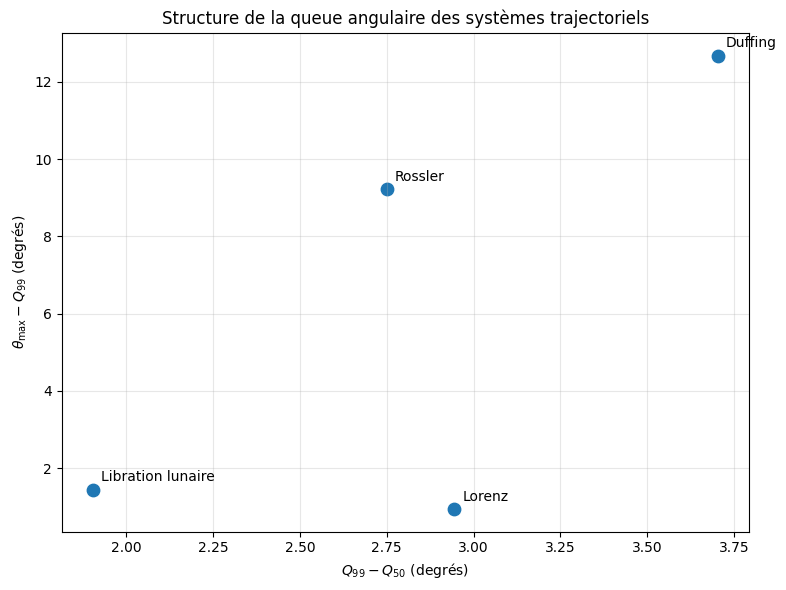

In [55]:
# Étape 53 — Plan descriptif des queues angulaires

import matplotlib.pyplot as plt

x_queue = comparaison_queue_angles["Q99_Q50"]
y_extreme = comparaison_queue_angles["Max_moins_Q99"]

plt.figure(figsize=(8, 6))

plt.scatter(
    x_queue,
    y_extreme,
    s=80
)

for _, ligne in comparaison_queue_angles.iterrows():
    plt.annotate(
        ligne["Systeme"],
        (
            ligne["Q99_Q50"],
            ligne["Max_moins_Q99"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel(r"$Q_{99}-Q_{50}$ (degrés)")
plt.ylabel(r"$\theta_{\max}-Q_{99}$ (degrés)")
plt.title("Structure de la queue angulaire des systèmes trajectoriels")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

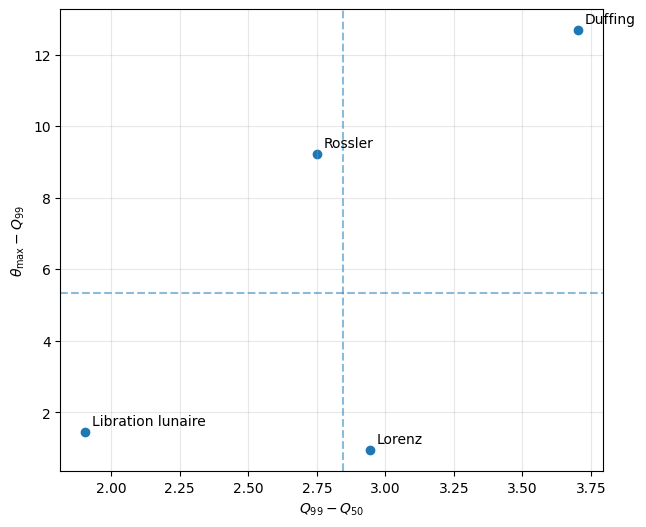

In [58]:
plt.figure(figsize=(7,6))

plt.scatter(
    comparaison_queue_angles["Q99_Q50"],
    comparaison_queue_angles["Max_moins_Q99"]
)

for _, row in comparaison_queue_angles.iterrows():
    plt.annotate(
        row["Systeme"],
        (row["Q99_Q50"], row["Max_moins_Q99"]),
        xytext=(5,5),
        textcoords="offset points"
    )

# Médianes
plt.axvline(
    comparaison_queue_angles["Q99_Q50"].median(),
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    comparaison_queue_angles["Max_moins_Q99"].median(),
    linestyle="--",
    alpha=0.5
)

plt.xlabel(r"$Q_{99}-Q_{50}$")
plt.ylabel(r"$\theta_{\max}-Q_{99}$")
plt.grid(True, alpha=0.3)

plt.show()